In [42]:
import snapatac2 as snap
import os
import sys
import scanpy as sc
import pandas as pd 
#sys.path.append('..')
#import Py_mTCall_tools.variant_calling
import importlib
#from Py_mTCall_tools import process_and_integrate_variants  # Use the package name from setup.py
import kaleido
import plotly.io as pio



In [43]:
data = snap.pp.import_fragments(
    "/Users/lucascortes/Documents/Pickett/Mike_Keogh/Data/241121-PBMC_results_masked/fragments.tsv.gz",
    chrom_sizes=snap.genome.hg38,  #
    sorted_by_barcode=False,
)
data          

AnnData object with n_obs × n_vars = 24325 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

2025-10-21 15:09:14 - INFO - Computing fragment size distribution...


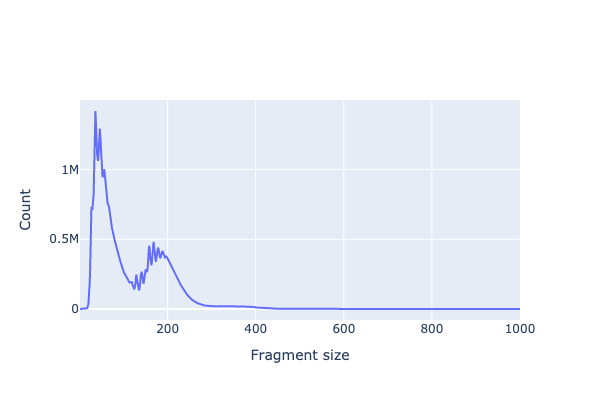

In [44]:
## Bit of extra information:
'''
1. Nucleosome-Free Region (NFR): The majority of fragments are short, typically around 80-300 base pairs (bp) in length. 
These short fragments represent regions of open chromatin where DNA is relatively accessible and not bound to nucleosomes. 
These regions are often referred to as nucleosome-free regions (NFRs) and correspond to regions of active transcriptional 
regulation.

2. Mono-Nucleosome Peaks: There is often a peak in the fragment size distribution at around 147-200 bp, 
which corresponds to the size of a single nucleosome wrapped DNA. These fragments result from the 
cutting of DNA by the transposase enzyme when it encounters a nucleosome, 
causing the DNA to be protected and resulting in fragments of the same size.

3. Di-Nucleosome Peaks: In addition to the mono-nucleosome peak, you may also observe 
a smaller peak at approximately 300-400 bp, corresponding to di-nucleosome fragments. 
These fragments occur when transposase cuts the DNA between two neighboring nucleosomes.

4. Large Fragments: Some larger fragments, greater than 500 bp in size, may be observed. 
These fragments can result from various sources, such as the presence of 
longer stretches of open chromatin or technical artifacts.
'''



snap.pl.frag_size_distr(data, interactive=False)

In [45]:
## Same plot with axis to log scale
fig = snap.pl.frag_size_distr(data, show=False)
fig.update_yaxes(type="log")
fig.show()

In [46]:
## TSS enrichment implies there is an increased accessibility or fragmentation of chromatin around the TSS
## Often indicative of promoter regions
snap.metrics.tsse(data, snap.genome.hg38)

In [47]:
## To identify usable/high-quality cells, we can plot TSSe scores against number of unique fragments for each cell.
snap.pl.tsse(data, interactive=False)
data

##The cells in the upper right represent valid or high-quality cells, whereas those in the lower left represent low-quality 
# cells or empty droplets. Based on this plot, 
#we decided to set a minimum TSS enrichment of 10 and a minimum number of fragments of 5,000 to filter the cells.

AnnData object with n_obs × n_vars = 24325 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [48]:
## OprionL - Filtering cells here results in fewer mitochondrial variants deteced
snap.pp.filter_cells(data, min_counts=1000, min_tsse=10, max_counts=100000)
data

AnnData object with n_obs × n_vars = 8110 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [49]:
## Cell by bin matrix containng insertion counts across 500bp bins across the genome
snap.pp.add_tile_matrix(data)

In [50]:
## Feature selection, which will be stored in data.var['selected'] this is particularly relevant for scrublet and spectral
## Selects most accessible features 
## n_features determines number of features, experiment with n_features to find the optimal number for your dataset
snap.pp.select_features(data, n_features=250000)

2025-10-21 15:09:23 - INFO - Selected 250000 features.


In [51]:
## Scrublet is used to remove potential dublets. It will assign probabilities to each cell, and then we can filter
snap.pp.scrublet(data)
snap.pp.filter_doublets(data)
data

2025-10-21 15:09:23 - INFO - Simulating doublets...
2025-10-21 15:09:24 - INFO - Spectral embedding ...
2025-10-21 15:10:42 - INFO - Calculating doublet scores...
2025-10-21 15:10:43 - INFO - Detected doublet rate = 5.968%


AnnData object with n_obs × n_vars = 7626 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate'
    obsm: 'fragment_paired'

In [52]:
## Spectral embedding is used for dimensionality reduction
## Stored in data.obsm['X_spectral']
snap.tl.spectral(data)
snap.tl.umap(data)

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [53]:
## Perform graph based clustering, build k-nearest neighbour graph then use leiden algorithm to identify clusters
snap.pp.knn(data)
snap.tl.leiden(data, resolution=0.7)  # Adjust resolution for more or fewer clusters

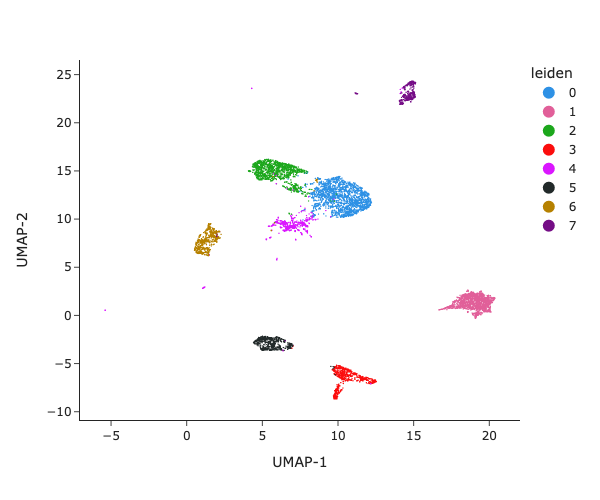

In [54]:
snap.pl.umap(data, color='leiden', interactive=False, height=500)

In [55]:
## Annotate the clusters and assign them to known cell types
## Compute gene activities for each cell using pp.make_gene_matrix

gene_matrix = snap.pp.make_gene_matrix(data, snap.genome.hg38)
print(f"Number of cells: {gene_matrix.n_obs}")
gene_matrix
data

Number of cells: 7626


AnnData object with n_obs × n_vars = 7626 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate', 'spectral_eigenvalue'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap'
    obsp: 'distances'

In [56]:
### The cell by gene activity matrix is sparse
## The MAGIC algorithm performs imputation and data smoothing
## Then scanpy does subsequent steps 
## First perform gene filtering, normalisation and transformation and then call MAGIC
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
# Skip MAGIC imputation - the analysis will work fine without it
# sc.external.pp.magic(gene_matrix, solver="approximate")

# Copy over UMAP embedding
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]

... storing 'leiden' as categorical


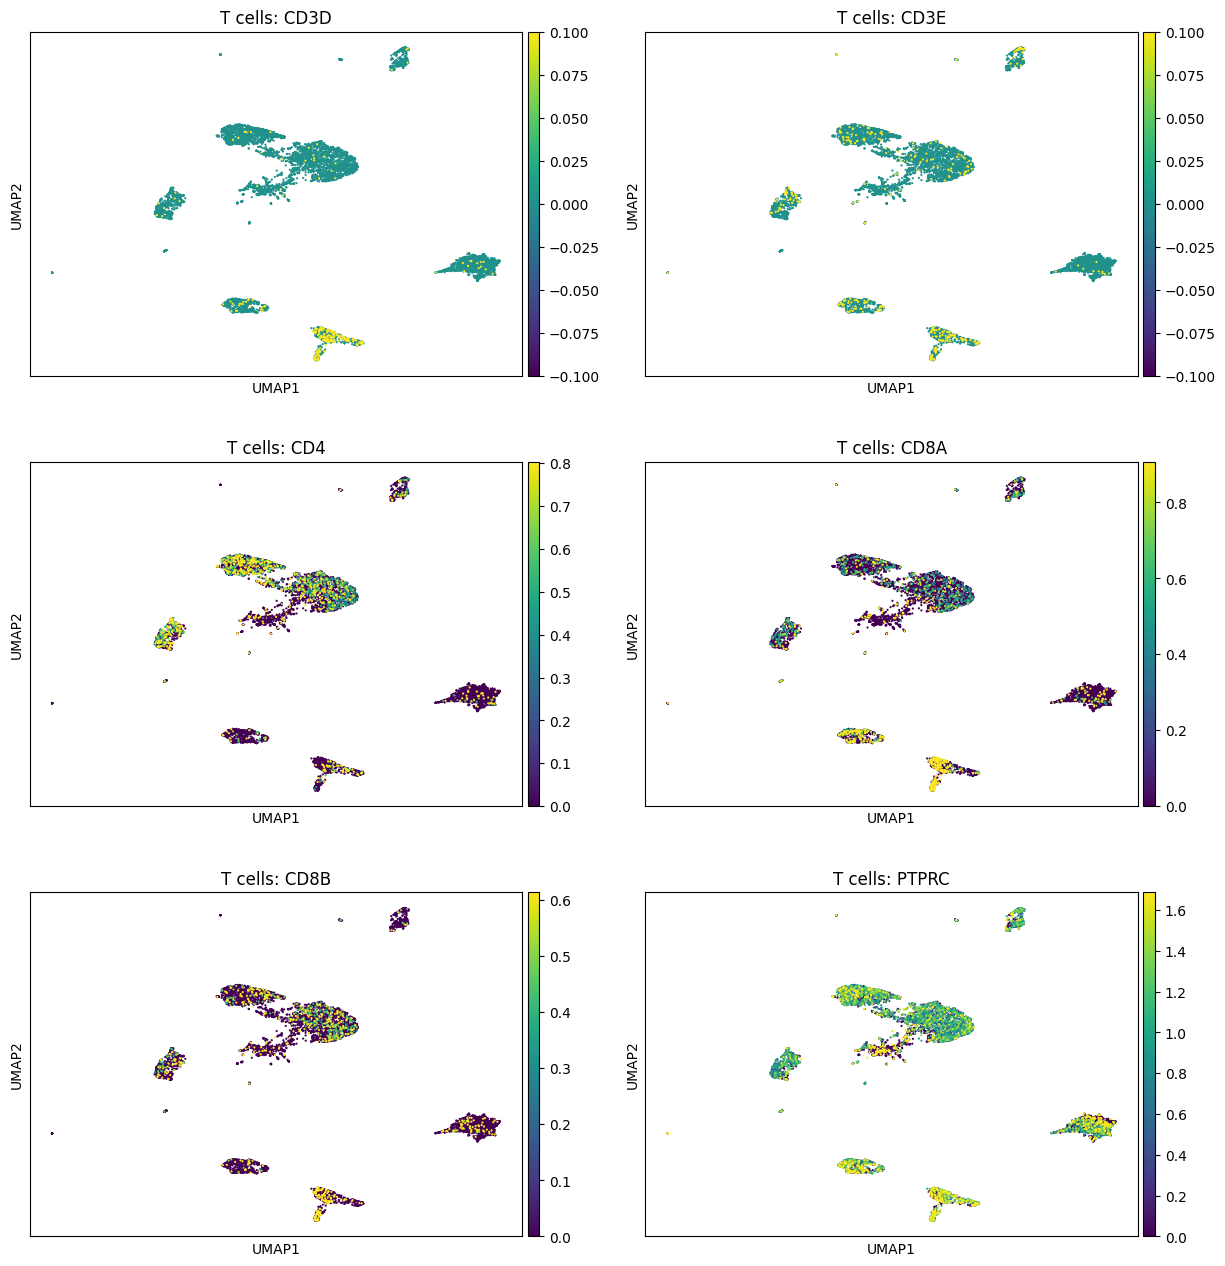

In [57]:
import matplotlib.pyplot as plt

# Define marker genes for each cell type
celltype_markers = {
    'T cells': ["CD3D", "CD3E", "CD4", "CD8A", "CD8B", "PTPRC"], ## PTPRC is CD45, sample should be 70/30 CD4+/CD4-
    
}

# Plot UMAPs for each cell type's marker genes
for celltype, genes in celltype_markers.items():
    sc.pl.umap(
        gene_matrix, 
        color=genes, 
        ncols=2, 
        cmap='viridis',
        vmax='p95',
        size=10,
        title=[f"{celltype}: {gene}" for gene in genes],
        show=True
    )
plt.show()


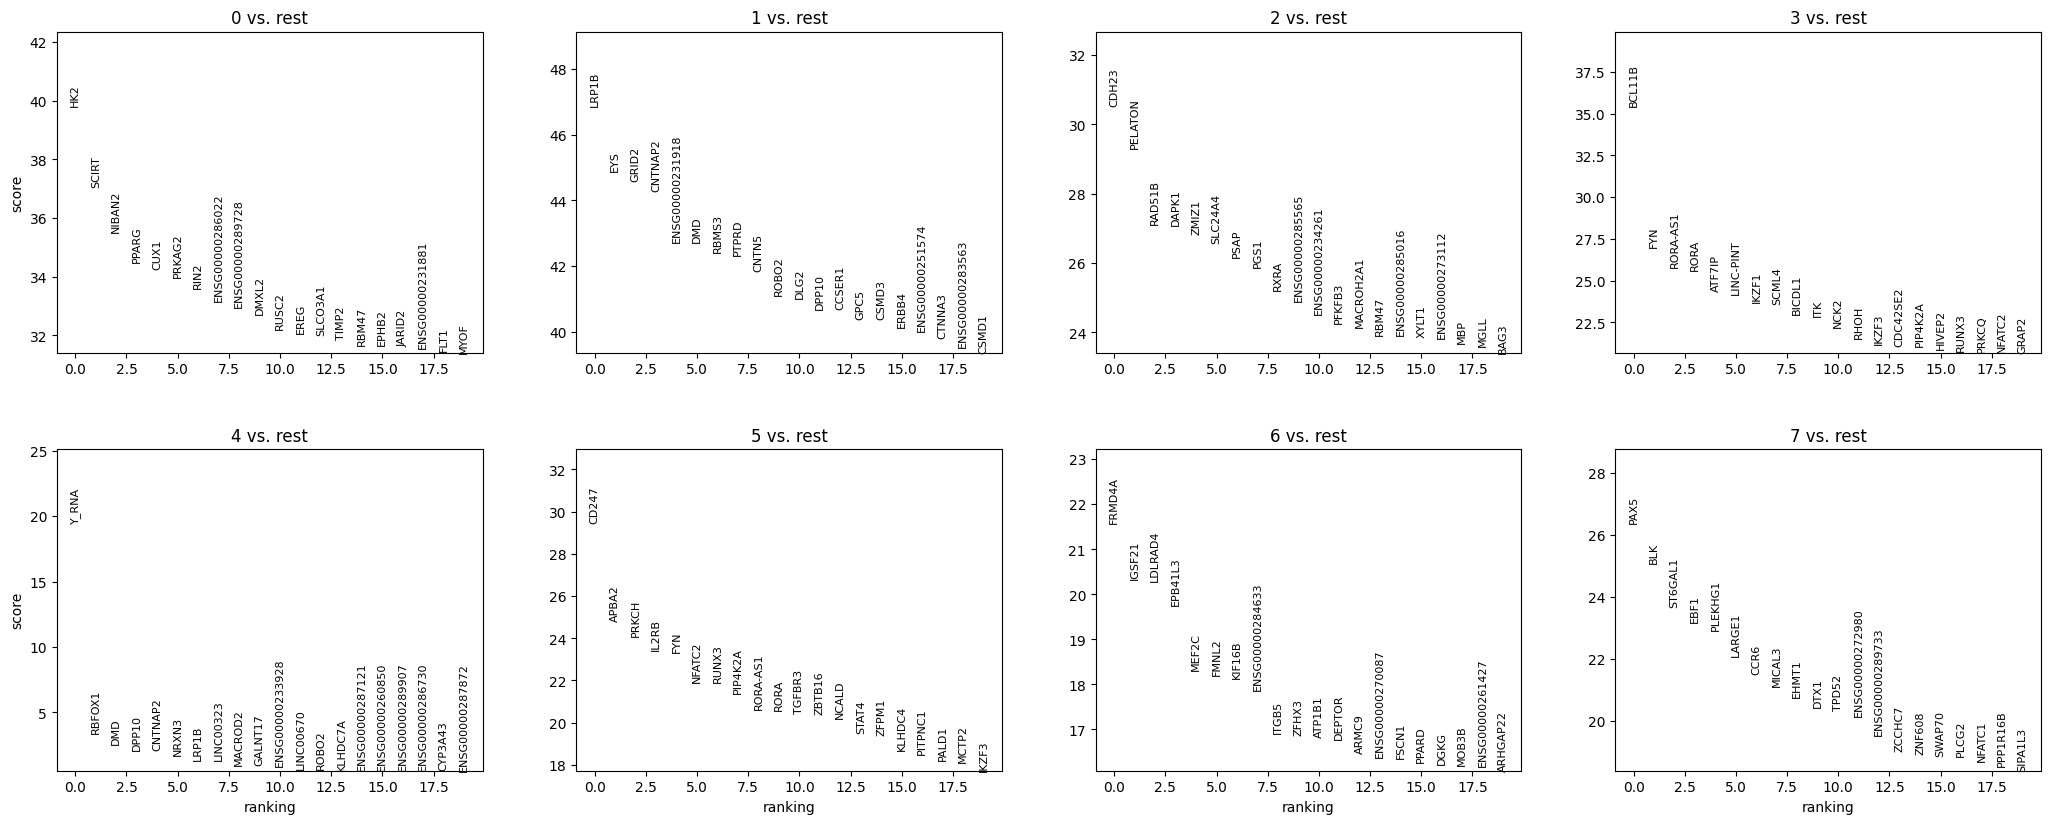

In [58]:
# Run differential expression analysis between clusters (e.g., 'leiden' clusters)
sc.tl.rank_genes_groups(gene_matrix, groupby='leiden', method='wilcoxon')

# Show the top marker genes for each cluster
sc.pl.rank_genes_groups(gene_matrix, n_genes=20, sharey=False)

In [59]:
##Not clear what the clusters are so I am going to do vague annotations
##Annotatig 
cluster_to_celltype = {
    "6": "CD4 T cell",
    "0": "Macrophage",
    "3": "CD8 T cell",
    "1": "NK cell",
    "2": "Monocytes",
    "4": "Unsure",
    "5": "Unsure",
    "7": "B cell"
   
    # Add more as needed
}

... storing 'celltype' as categorical


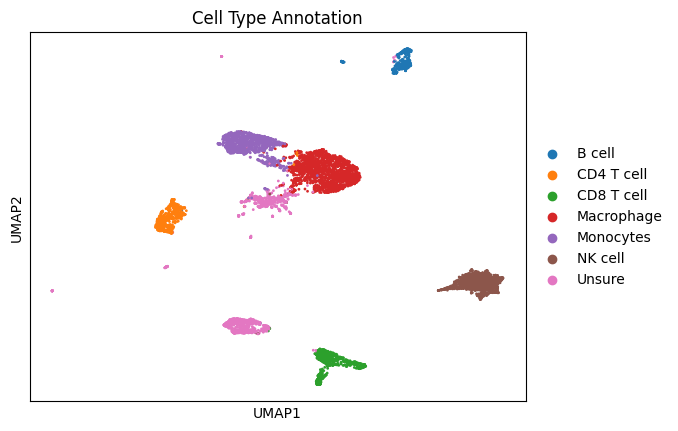

In [60]:
gene_matrix.obs['celltype'] = gene_matrix.obs['leiden'].map(cluster_to_celltype)
sc.pl.umap(gene_matrix, color=['celltype'], title="Cell Type Annotation")

In [61]:
import sys
sys.path.insert(0, '/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Py-mTCall')
# Fix: Use uppercase 'Py_mTCall_tools' instead of lowercase 'py_mTCall_tools'
import Py_mTCall_tools.variant_calling_fast as vc
mgatk = vc.process_variants_fast("/Users/lucascortes/Documents/Pickett/Mike_Keogh/Data/241121-PBMC_results_masked/final", gene_matrix)



=== Memory-Optimized Variant Calling Pipeline ===
Loading allele count data...
Loaded counts data: (132095, 8368)
Sample positions in counts: ['1', '10', '100', '1000', '10000', '10001', '10002', '10003', '10004', '10005']
Loading reference and coverage data...
Loaded refallele data: (16569, 2)
Sample positions in refallele: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
=== Fast Variant Calling Pipeline ===
Loading allele count data...
Loaded counts data: (132095, 8368)
Sample positions in counts: ['1', '10', '100', '1000', '10000', '10001', '10002', '10003', '10004', '10005']
Loading reference and coverage data...
Loaded refallele data: (16569, 2)
Sample positions in refallele: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Pre-filtering coverage data to variant positions only...
Found 16569 positions with variants
L

In [62]:
variants = mgatk.uns['variant_names']
variants_formatted = []
for i in range(len(variants)):
    parts = variants[i].split('-')
    variants_formatted.append(parts[1] + parts[2] + '>' + parts[0])
variants_swapped_df = pd.DataFrame(variants_formatted, columns=['variant'])
variants_swapped_df.to_csv("/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/Mike_Keogh/analysis/PBMC_Surgical/PBMC_Surgical_variants_swapped.csv", index=False)
signac_variants = pd.read_csv("/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/Mike_Keogh/analysis/PBMC_Surgical/PBMC_surgical_variants_mgatk.csv", header=0)
signac_variants = signac_variants.iloc[:, 1]
signac_variants_list = signac_variants.tolist()

# Compare the two lists
matching_variants = set(variants_formatted).intersection(set(signac_variants_list))
print(f"Matching variants: {matching_variants}")
print(len(matching_variants))

Matching variants: {'3226G>A', '5578T>C', '618T>C', '4939T>C', '916C>T', '7176T>C', '788T>C', '15726T>C', '13064T>C', '5634A>T', '8986A>G', '4728A>G', '9592T>C', '929A>G', '1100C>A', '11184G>A', '13070C>T', '8854G>A', '2813T>C', '7797T>C', '297A>G', '830T>G', '9136A>G', '1079G>A', '9589A>G', '7411A>G', '8618T>C', '3916G>A', '12223A>G', '7842T>C', '5006A>T', '1888G>A', '10161A>G', '368A>G', '15027T>C', '525C>T', '15183T>C', '14904T>C', '3127G>A', '8556T>C', '11964T>C', '7296G>A', '12170G>A', '15687G>A', '3656T>C', '4449G>A', '11800A>G', '1180T>C', '6176T>C', '2174G>A', '466T>C', '2861A>T', '6799T>C', '1178G>A', '11561G>A', '12443T>C', '12681T>C', '5608C>G', '13345G>A', '11316T>C', '8093T>C', '5951A>G', '10692C>T', '7025A>G', '5698G>A', '3919T>C', '3022G>A', '1172C>T', '13208G>A', '11140C>T', '6356C>T', '7100A>G', '3682A>C', '14123T>C', '16169C>T', '6371C>T', '7673A>G', '3118T>C', '11948G>A', '1380G>A', '8900T>C', '4290T>C', '12808T>C', '14152A>G', '10654C>A', '2932G>A', '15235A>C', '131

Plotting first 5 confident variants out of 4710 total confident variants
Processing variant 1: Index 0, Name: A-10172-G


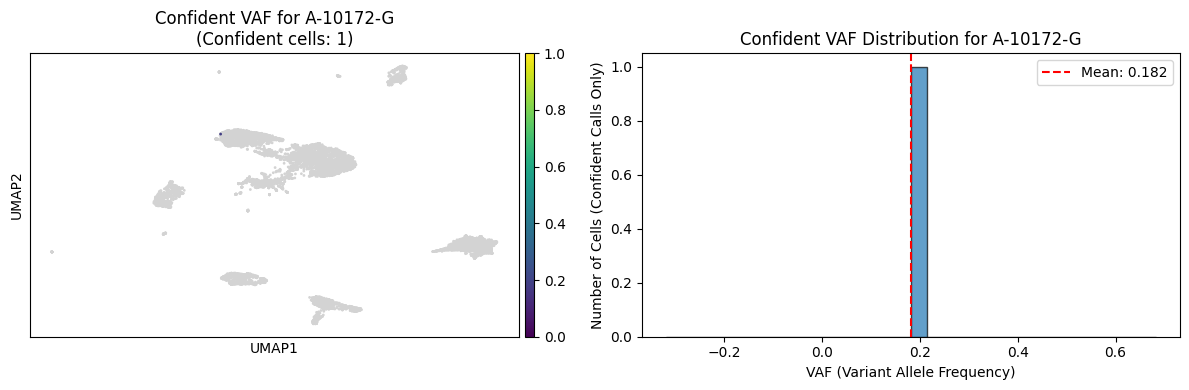

Variant A-10172-G (Index 0):
  Confident cells detected: 1
  Mean coverage: 24.7
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.182
  Confident VAF range: 0.182 - 0.182
---
Processing variant 2: Index 1, Name: A-10726-G


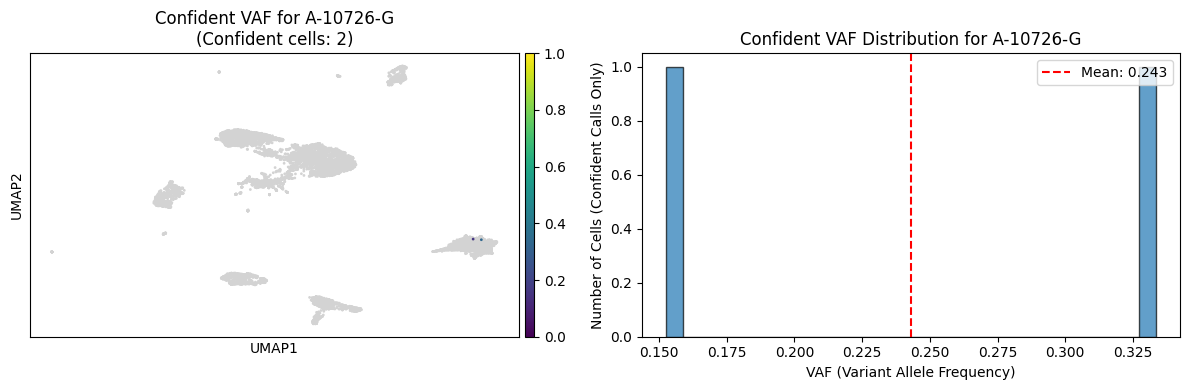

Variant A-10726-G (Index 1):
  Confident cells detected: 2
  Mean coverage: 20.0
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 2
  Mean confident VAF: 0.243
  Confident VAF range: 0.153 - 0.333
---
Processing variant 3: Index 2, Name: A-11163-G


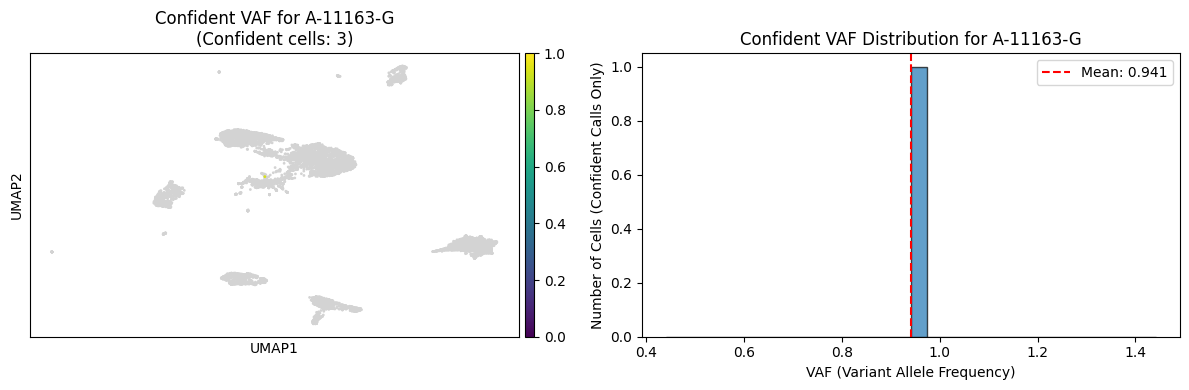

Variant A-11163-G (Index 2):
  Confident cells detected: 3
  Mean coverage: 30.0
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.941
  Confident VAF range: 0.941 - 0.941
---
Processing variant 4: Index 3, Name: A-11225-G
No confident non-zero calls for variant A-11225-G
Processing variant 5: Index 4, Name: A-11382-C


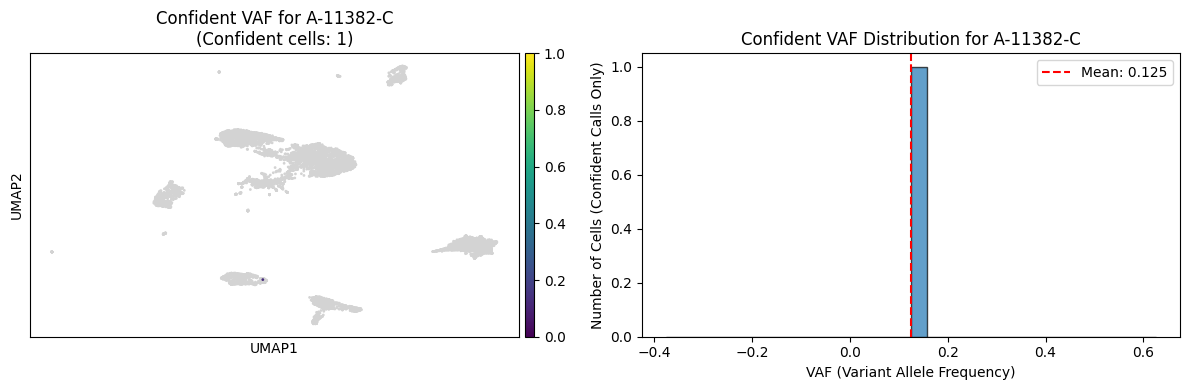

Variant A-11382-C (Index 4):
  Confident cells detected: 1
  Mean coverage: 15.6
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.125
  Confident VAF range: 0.125 - 0.125
---


In [65]:
# Plot confident variants with UMAP and VAF distribution
import matplotlib.pyplot as plt
import numpy as np

# Get confident variants (those with at least one cell having confident detection)
confident_variants = mgatk.uns['variant_summary'][mgatk.uns['variant_summary']['n_cells_conf_detected'] > 0]

print(f"Plotting first 5 confident variants out of {len(confident_variants)} total confident variants")

# Get the variant names list
variant_names = mgatk.uns['variant_names']

for i, variant_idx in enumerate(confident_variants.index[:5]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    
    print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")
    
    # Get VAF and confident matrices
    vaf_matrix = mgatk.obsm['variant_vaf']
    confident_matrix = mgatk.obsm['variant_confident']
    
    # Extract VAF and confidence for this specific variant using the integer index
    vaf_values = vaf_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Filter for confident calls AND non-zero VAF
    confident_and_nonzero_mask = confident_calls & (vaf_values > 0)
    
    if not confident_and_nonzero_mask.any():
        print(f"No confident non-zero calls for variant {variant_name}")
        continue
    
    # Get filtered VAF values
    filtered_vaf_values = vaf_values[confident_and_nonzero_mask]
    
    # Create a temporary column for plotting (confident calls only)
    temp_vaf_col = np.zeros(len(mgatk.obs))
    temp_vaf_col[confident_and_nonzero_mask] = filtered_vaf_values
    # Set non-confident or zero calls to NaN for proper plotting
    temp_vaf_col[~confident_and_nonzero_mask] = np.nan
    
    # Add temporary column to obs for plotting
    mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # UMAP plot (only confident calls will be colored)
    sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1, 
               title=f"Confident VAF for {variant_name}\n(Confident cells: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']})", 
               ax=ax1, show=False, na_color='lightgray')
    
    # Histogram of confident VAF values only
    ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('VAF (Variant Allele Frequency)')
    ax2.set_ylabel('Number of Cells (Confident Calls Only)')
    ax2.set_title(f'Confident VAF Distribution for {variant_name}')
    ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
                label=f'Mean: {filtered_vaf_values.mean():.3f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_cells = len(mgatk.obs)
    confident_cells = confident_calls.sum()
    confident_nonzero_cells = len(filtered_vaf_values)
    
    print(f"Variant {variant_name} (Index {variant_idx}):")
    print(f"  Confident cells detected: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']}")
    print(f"  Mean coverage: {confident_variants.loc[variant_idx, 'mean_coverage']:.1f}")
    print(f"  Total cells: {total_cells}")
    print(f"  Confident calls: {confident_calls}")
    print(f"  Confident non-zero calls: {confident_nonzero_cells}")
    print(f"  Mean confident VAF: {filtered_vaf_values.mean():.3f}")
    print(f"  Confident VAF range: {filtered_vaf_values.min():.3f} - {filtered_vaf_values.max():.3f}")
    print("---")
    
    # Clean up temporary column
    mgatk.obs.drop(columns=[f'temp_vaf_{variant_idx}'], inplace=True)

Variant A-10172-G: Insufficient data points (1)
Variant A-10726-G: Insufficient data points (2)
Variant A-11163-G: Insufficient data points (1)
Variant A-11225-G: Insufficient data points (0)
Variant A-11382-C: Insufficient data points (1)
Variant A-11415-C: Insufficient data points (1)


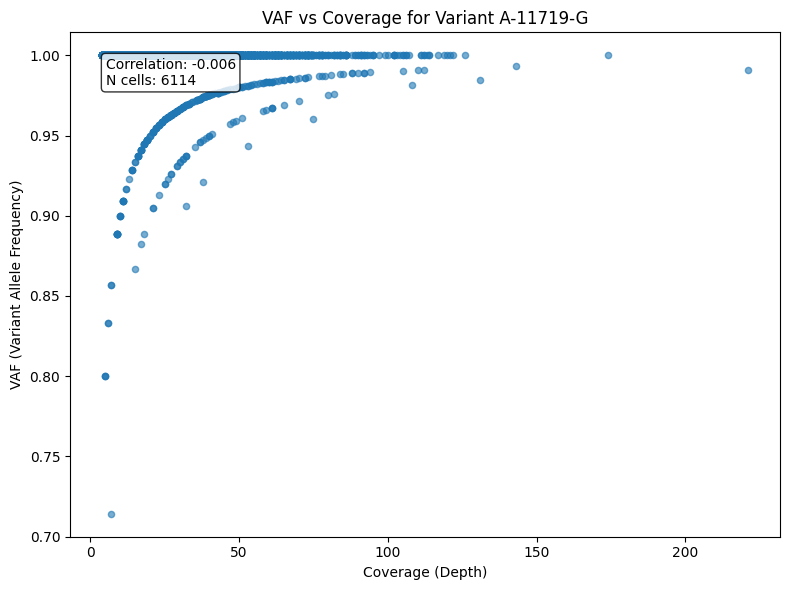

Variant A-11719-G:
  Coverage range: 4.0 - 221.0
  Mean coverage: 25.3
  VAF range: 0.714 - 1.000
  Correlation (VAF vs Coverage): -0.006
---


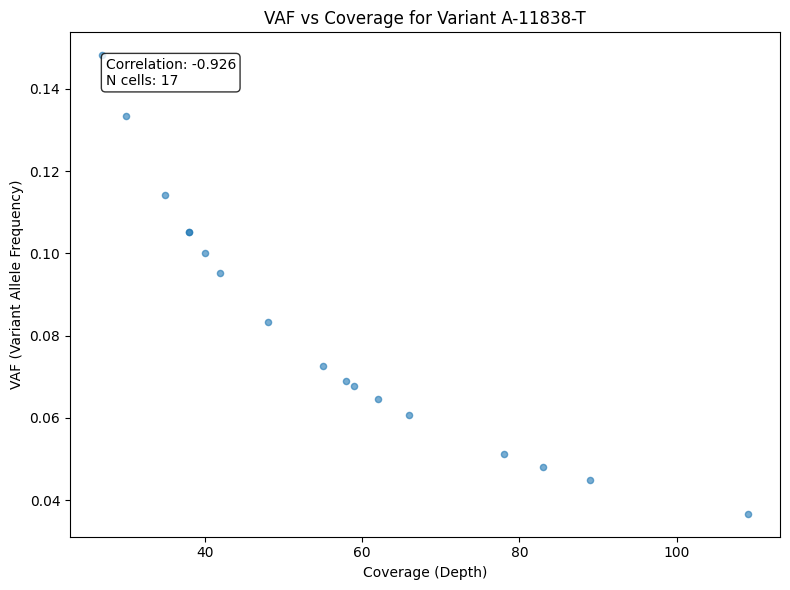

Variant A-11838-T:
  Coverage range: 27.0 - 109.0
  Mean coverage: 56.3
  VAF range: 0.037 - 0.148
  Correlation (VAF vs Coverage): -0.926
---
Variant A-11858-C: Insufficient data points (1)
Variant A-1204-C: Insufficient data points (1)
Variant A-12412-C: Insufficient data points (1)


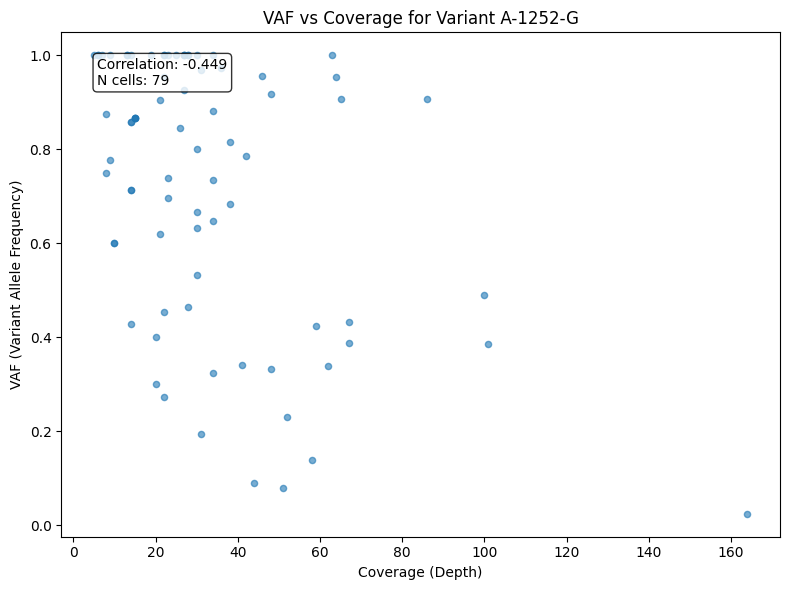

Variant A-1252-G:
  Coverage range: 5.0 - 164.0
  Mean coverage: 32.8
  VAF range: 0.024 - 1.000
  Correlation (VAF vs Coverage): -0.449
---
Variant A-12583-G: Insufficient data points (2)
Variant A-12861-C: Insufficient data points (1)
Variant A-13043-C: Insufficient data points (1)
Variant A-13094-T: Insufficient data points (0)
Variant A-13329-C: Insufficient data points (1)
Variant A-13558-G: Insufficient data points (1)
Variant A-13694-C: Insufficient data points (1)
Variant A-13730-G: Insufficient data points (1)
Variant A-13879-T: Insufficient data points (1)
Variant A-14721-G: Insufficient data points (1)
Variant A-1476-G: Insufficient data points (2)
Variant A-14991-T: Insufficient data points (0)
Variant A-15093-G: Insufficient data points (3)
Variant A-15170-G: Insufficient data points (0)
Variant A-15301-G: Insufficient data points (3)
Variant A-15708-G: Insufficient data points (4)


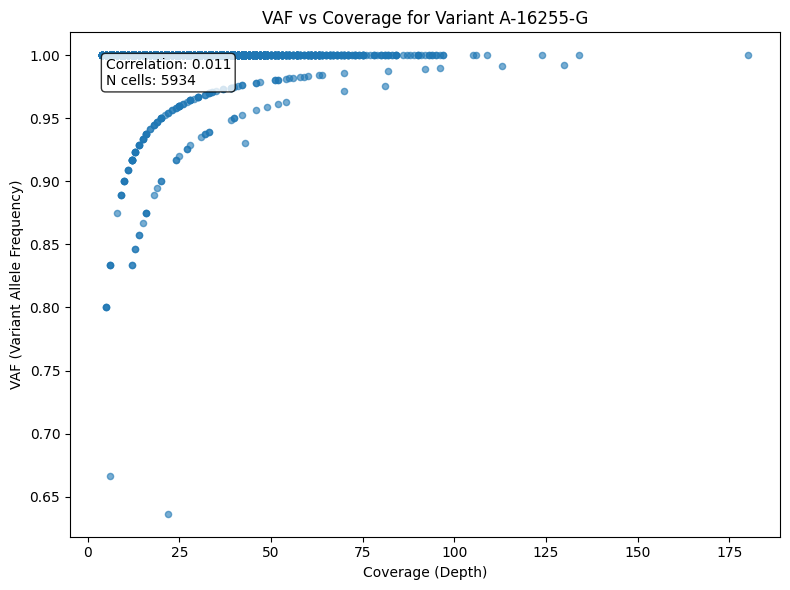

Variant A-16255-G:
  Coverage range: 4.0 - 180.0
  Mean coverage: 20.7
  VAF range: 0.636 - 1.000
  Correlation (VAF vs Coverage): 0.011
---


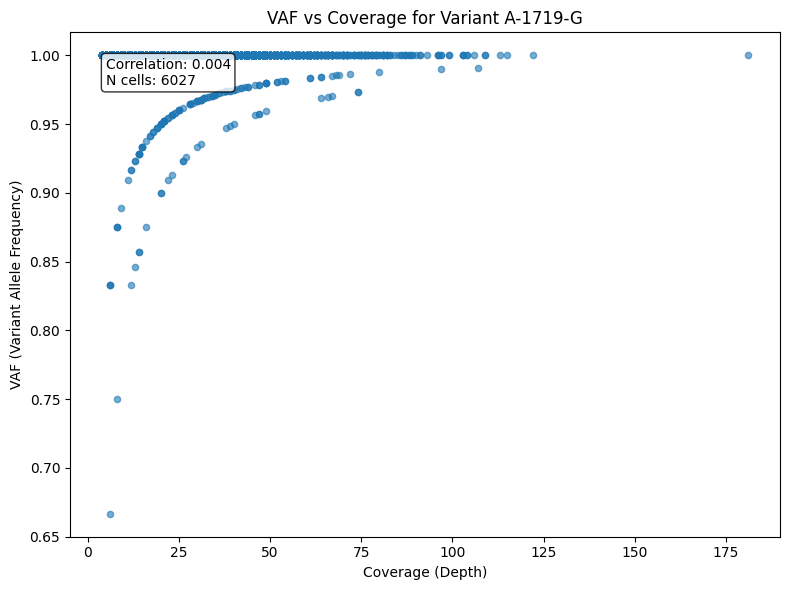

Variant A-1719-G:
  Coverage range: 4.0 - 181.0
  Mean coverage: 23.1
  VAF range: 0.667 - 1.000
  Correlation (VAF vs Coverage): 0.004
---


In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Get the matrices and variant info
vaf_matrix = mgatk.obsm['variant_vaf']        # cells x variants
coverage_matrix = mgatk.obsm['variant_coverage']  # cells x variants  
variant_names = mgatk.uns['variant_names']

# For variants in your confident_variants
for i, variant_idx in enumerate(confident_variants.index[:30]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    try:
        variant_idx = confident_variants.index[i]  # Get the actual variant index
        # Find the index of this variant in the variant_names list
        variant_idx = variant_names.index(variant_name)
        
        # Get VAF and coverage values for this variant across all cells
        vaf_values = vaf_matrix[:, variant_idx]
        coverage_values = coverage_matrix[:, variant_idx]
        
        # Filter for cells with non-zero VAF and valid coverage
        mask = (vaf_values > 0) & (coverage_values > 0)
        
        if mask.sum() > 5:  # Need at least 5 points for meaningful plot
            filtered_vaf = vaf_values[mask]
            filtered_coverage = coverage_values[mask]
            
            # Create scatter plot
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            scatter = ax.scatter(filtered_coverage, filtered_vaf, alpha=0.6, s=20)
            ax.set_xlabel('Coverage (Depth)')
            ax.set_ylabel('VAF (Variant Allele Frequency)')
            ax.set_title(f'VAF vs Coverage for Variant {variant_name}')
            
            # Add statistics
            if len(filtered_coverage) > 1 and len(set(filtered_coverage)) > 1:
                correlation = np.corrcoef(filtered_coverage, filtered_vaf)[0, 1]
            else:
                correlation = np.nan
                
            ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}\nN cells: {len(filtered_vaf)}', 
                    transform=ax.transAxes, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(f"Variant {variant_name}:")
            print(f"  Coverage range: {filtered_coverage.min():.1f} - {filtered_coverage.max():.1f}")
            print(f"  Mean coverage: {filtered_coverage.mean():.1f}")
            print(f"  VAF range: {filtered_vaf.min():.3f} - {filtered_vaf.max():.3f}")
            print(f"  Correlation (VAF vs Coverage): {correlation:.3f}")
            print("---")
        else:
            print(f"Variant {variant_name}: Insufficient data points ({mask.sum()})")
            
    except Exception as e:
        print(f"Error processing variant {variant_name}: {e}")

In [ ]:
import numpy as np
import pandas as pd

# Get the matrices
vaf_matrix = mgatk.obsm['variant_vaf'].copy()  # Make a copy to modify
coverage_matrix = mgatk.obsm['variant_coverage']
confident_matrix = mgatk.obsm['variant_confident']
variant_names = mgatk.uns['variant_names']
variant_summary = mgatk.uns['variant_summary']

print(f"Original VAF matrix shape: {vaf_matrix.shape}")
print(f"Non-zero VAF values before filtering: {(vaf_matrix > 0).sum()}")

# Count variants with at least one expressing cell before filtering
variants_with_expression_before = (vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell before filtering: {variants_with_expression_before}")

# Create high-quality filtered VAF matrix
high_quality_vaf_matrix = vaf_matrix.copy()
variant_names_list = []
# For each variant, apply cell-level quality filters
for i, variant_name in enumerate(variant_names):
    # Get variant-level statistics
    variant_stats = variant_summary.iloc[i]
    strand_concordance = variant_stats['strand_concordance']
    variance = variant_stats['variance'] 
    mean_coverage = variant_stats['mean_coverage']
    
    # Get cell-level data for this variant
    cell_vaf = vaf_matrix[:, i]
    cell_coverage = coverage_matrix[:, i]
    cell_confident = confident_matrix[:, i]
    
    # Define quality criteria for this variant's cells
    quality_mask = (
        (strand_concordance >= 0.5) &  # Variant-level criterion
        (mean_coverage >= 20) &        # Variant-level criterion
        (cell_vaf >= 0.1)        # Cell-level: VAF > 10%
    )
    
    # Set non-qualifying cells to 0 for this variant
    high_quality_vaf_matrix[~quality_mask, i] = 0

print(f"Non-zero VAF values after high-quality filtering: {(high_quality_vaf_matrix > 0).sum()}")
print(f"Percentage of calls retained: {(high_quality_vaf_matrix > 0).sum() / (vaf_matrix > 0).sum() * 100:.1f}%")

# Count variants with at least one expressing cell after filtering
variants_with_expression_after = (high_quality_vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell after filtering: {variants_with_expression_after}")
print(f"Percentage of variants retained: {variants_with_expression_after / variants_with_expression_before * 100:.1f}%")

# Count variants completely eliminated by filtering
variants_eliminated = variants_with_expression_before - variants_with_expression_after
print(f"Variants completely eliminated by filtering: {variants_eliminated}")
print("variants left" , variants_with_expression_after)
# Store the high-quality filtered matrix
mgatk.obsm['variant_vaf_high_quality'] = high_quality_vaf_matrix

# Now you can use this filtered matrix for analysis
print("\nHigh-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']")

Original VAF matrix shape: (7626, 4710)
Non-zero VAF values before filtering: 169464
Variants with at least one expressing cell before filtering: 4113
Non-zero VAF values after high-quality filtering: 71866
Percentage of calls retained: 42.4%
Variants with at least one expressing cell after filtering: 2363
Percentage of variants retained: 57.5%
Variants completely eliminated by filtering: 1750
variants left 2363

High-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']


In [96]:
# Boolean mask: True for variants with at least one retained (non-zero) cell
high_quality_mask = (high_quality_vaf_matrix > 0).any(axis=0)

# Get corresponding variant names
high_quality_variant_names = np.array(variant_names)[high_quality_mask]
print(high_quality_variant_names)
print(len(high_quality_variant_names))

## Flip variants to match format 
converted = [f"MT-{alt}-{pos}-{ref}" for ref, pos, alt in (v.split('-') for v in high_quality_variant_names)]
print(converted)

required_columns = ["chr", "pos", "ref", "alt"]

genebe_df = pd.DataFrame(
    [v.split('-') for v in converted],
    columns=["chr","ref", "pos", "alt"]
)
genebe_df = genebe_df[required_columns]

print(genebe_df.head())

['A-10172-G' 'A-11163-G' 'A-11719-G' ... 'G-8784-A' 'G-8860-A' 'G-982-A']
2363
['MT-G-10172-A', 'MT-G-11163-A', 'MT-G-11719-A', 'MT-T-11838-A', 'MT-C-12412-A', 'MT-G-1252-A', 'MT-G-12583-A', 'MT-C-12861-A', 'MT-G-13558-A', 'MT-G-13730-A', 'MT-G-1476-A', 'MT-G-15093-A', 'MT-G-15301-A', 'MT-G-15708-A', 'MT-G-1719-A', 'MT-G-1949-A', 'MT-G-2174-A', 'MT-G-2553-A', 'MT-G-3688-A', 'MT-G-3850-A', 'MT-c-4393-A', 'MT-G-4482-A', 'MT-G-4830-A', 'MT-G-4849-A', 'MT-G-5245-A', 'MT-G-529-A', 'MT-G-5590-A', 'MT-G-6069-A', 'MT-G-6999-A', 'MT-G-7239-A', 'MT-G-769-A', 'MT-G-8007-A', 'MT-G-8189-A', 'MT-G-874-A', 'MT-G-9267-A', 'MT-G-9554-A', 'MT-G-9906-A', 'MT-G-10172-C', 'MT-T-11147-C', 'MT-T-11759-C', 'MT-T-11784-C', 'MT-T-12448-C', 'MT-T-12755-C', 'MT-T-12851-C', 'MT-T-13698-C', 'MT-T-13781-C', 'MT-T-13946-C', 'MT-T-1413-C', 'MT-T-14345-C', 'MT-T-14395-C', 'MT-T-14819-C', 'MT-T-14826-C', 'MT-T-14912-C', 'MT-T-14956-C', 'MT-G-15301-C', 'MT-T-15394-C', 'MT-T-15519-C', 'MT-T-15755-C', 'MT-T-15774-C', 'MT-T

In [97]:
import genebe as gnb
annotated_PBMC = gnb.annotate_dataframe_variants(genebe_df,use_ensembl=True,use_refseq=False, genome='hg38', flatten_consequences=False)

2025-10-21 16:06:46 - WARNING - You are not logged in to GeneBe. We recommend using username and api_key arguments. Find out more on https://genebe.net/api .


Error: .netrc file not found.


100%|██████████| 24/24 [00:11<00:00,  2.17it/s]


In [ ]:
annotated_PBMC.to_csv('PBMC_PostMortem_genebe.csv', index=False)

In [98]:
#Gene classification 
gene_classification = {
    'MT-ND1': 'Complex I',
    'MT-ND2': 'Complex I',
    'MT-ND3': 'Complex I',
    'MT-ND4': 'Complex I',
    'MT-ND4L': 'Complex I',
    'MT-ND5': 'Complex I',
    'MT-ND6': 'Complex I',
    'MT-CO1': 'Complex IV',
    'MT-CO2': 'Complex IV',
    'MT-CO3': 'Complex IV',
    'MT-CYB': 'Complex III',
    'MT-ATP6': 'Complex V',
    'MT-ATP8': 'Complex V',
    'MT-RNR1': 'rRNA',
    'MT-RNR2': 'rRNA',
    'MT-TF': 'tRNA',  
    'MT-TV': 'tRNA',
    'MT-TI': 'tRNA',
    'MT-TL1': 'tRNA',
    'MT-TL2': 'tRNA',
    'MT-TK': 'tRNA',
    'MT-TM': 'tRNA',
    'MT-TP': 'tRNA',
    'MT-TS1': 'tRNA',
    'MT-TS2': 'tRNA',
    'MT-TW': 'tRNA',
    'MT-TA': 'tRNA',
    'MT-TC': 'tRNA',
    'MT-TY': 'tRNA',
    'MT-TH': 'tRNA',
    'MT-TG': 'tRNA',
    'MT-TR': 'tRNA',
    'MT-TN': 'tRNA',
    'MT-TD': 'tRNA',
    'MT-TE': 'tRNA',
    'MT-TQ': 'tRNA'
}

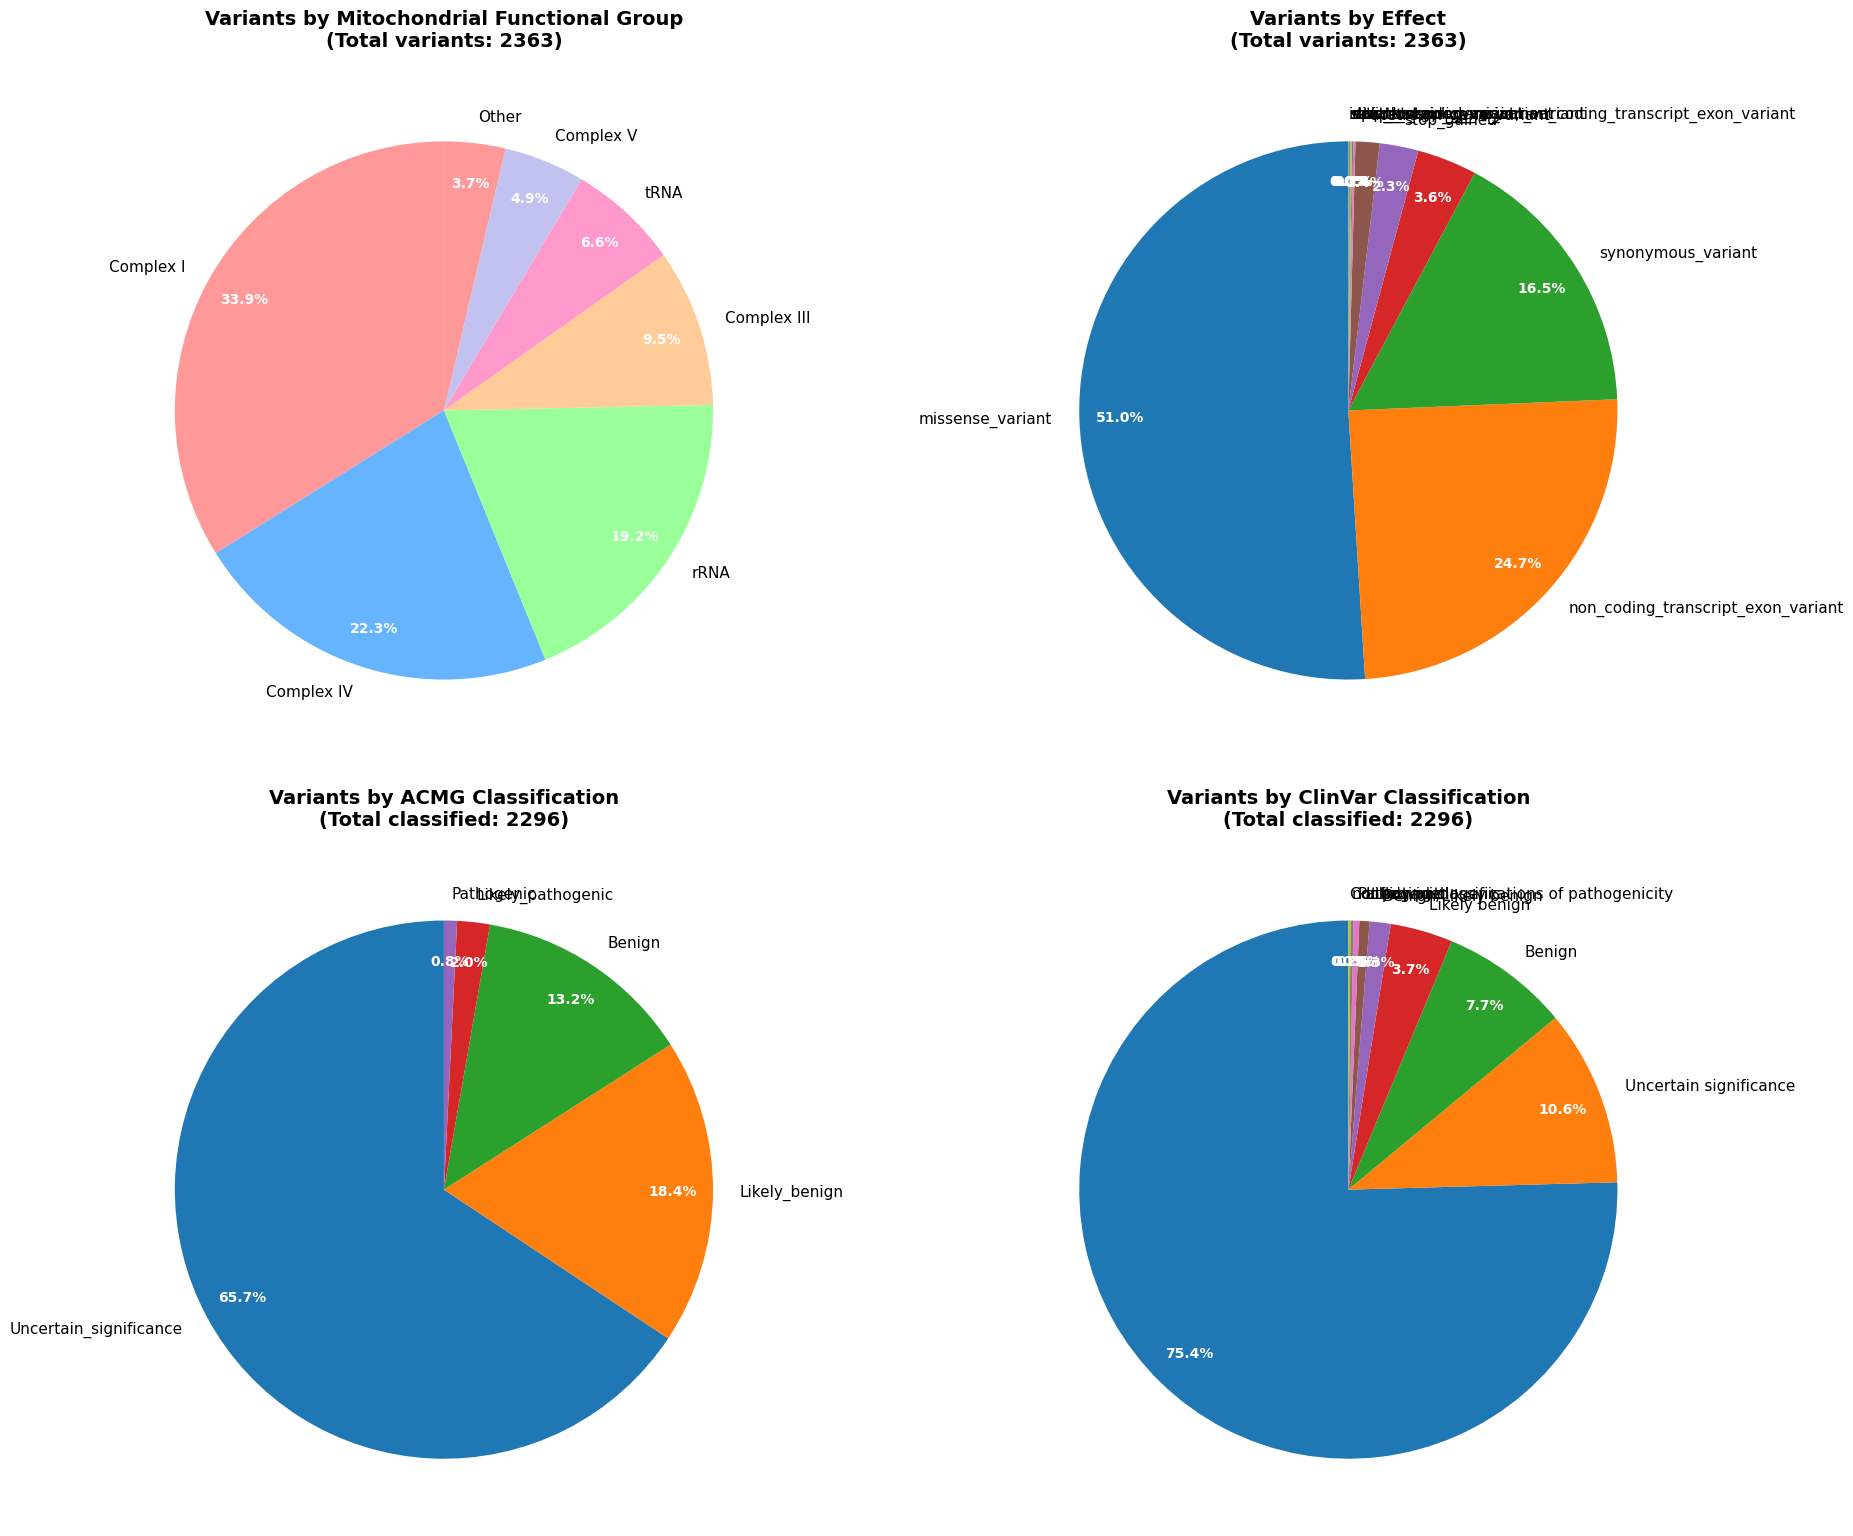

=== SUMMARY STATISTICS ===

1. Mitochondrial Functional Group Distribution:
   Total functional groups represented: 7
   Most common functional group: Complex I (801 variants)
   All functional groups:
      Complex I: 801 variants (33.9%)
      Complex IV: 526 variants (22.3%)
      rRNA: 453 variants (19.2%)
      Complex III: 224 variants (9.5%)
      tRNA: 157 variants (6.6%)
      Complex V: 115 variants (4.9%)
      Other: 87 variants (3.7%)

2. Individual Gene Symbol Distribution:
   Total genes represented: 29
   Most common gene: MT-ND5 (273 variants)
   Top 10 genes:
      1. MT-ND5 (Complex I): 273 variants (11.6%)
      2. MT-CO1 (Complex IV): 270 variants (11.4%)
      3. MT-RNR2 (rRNA): 240 variants (10.2%)
      4. MT-CYB (Complex III): 224 variants (9.5%)
      5. MT-RNR1 (rRNA): 213 variants (9.0%)
      6. MT-ND4 (Complex I): 168 variants (7.1%)
      7. MT-ND1 (Complex I): 145 variants (6.1%)
      8. MT-CO3 (Complex IV): 134 variants (5.7%)
      9. MT-CO2 (Complex 

In [99]:
# Create a copy of the dataframe and add the functional classification
annotated_PBMC_classified = annotated_PBMC.copy()
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_symbol'].map(gene_classification)

# Handle any genes not in the classification (mark as 'Other')
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_functional_group'].fillna('Other')

# Create a 2x2 subplot layout for the pie charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))  # Increased figure size

# Function to prepare data for pie chart (handle NaN values and limit categories)
def prepare_pie_data(series, max_categories=20):
    # Count values, excluding NaN
    value_counts = series.value_counts(dropna=True)
    
    # If there are more categories than max_categories, group the smallest ones as "Other"
    if len(value_counts) > max_categories:
        top_categories = value_counts.head(max_categories - 1)
        other_count = value_counts.iloc[max_categories - 1:].sum()
        
        # Create new series with "Other" category
        pie_data = top_categories.copy()
        pie_data['Other'] = other_count
    else:
        pie_data = value_counts
    
    return pie_data

# 1. Gene Functional Group pie chart (using your classification)
gene_functional_data = prepare_pie_data(annotated_PBMC_classified['gene_functional_group'])
colors1 = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']  # Custom colors for complexes

# Option 1: Use pctdistance and labeldistance to control spacing
wedges1, texts1, autotexts1 = ax1.pie(gene_functional_data.values, labels=gene_functional_data.index, 
                                       autopct='%1.1f%%', startangle=90, 
                                       colors=colors1[:len(gene_functional_data)],
                                       pctdistance=0.85,    # Distance of percentage labels from center
                                       labeldistance=1.1)   # Distance of category labels from center

# Adjust text properties to prevent overlap
for autotext in autotexts1:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts1:
    text.set_fontsize(11)

ax1.set_title(f'Variants by Mitochondrial Functional Group\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 2. Effect pie chart with adjusted spacing
effect_data = prepare_pie_data(annotated_PBMC['effect'])
wedges2, texts2, autotexts2 = ax2.pie(effect_data.values, labels=effect_data.index, 
                                       autopct='%1.1f%%', startangle=90,
                                       pctdistance=0.85, labeldistance=1.1)

for autotext in autotexts2:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts2:
    text.set_fontsize(11)

ax2.set_title(f'Variants by Effect\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 3. ACMG Classification pie chart
acmg_data = prepare_pie_data(annotated_PBMC['acmg_classification'])
if len(acmg_data) > 0:
    wedges3, texts3, autotexts3 = ax3.pie(acmg_data.values, labels=acmg_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts3:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts3:
        text.set_fontsize(11)
    
    ax3.set_title(f'Variants by ACMG Classification\n(Total classified: {acmg_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax3.text(0.5, 0.5, 'No ACMG Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax3.set_title('ACMG Classification', fontsize=14, fontweight='bold', pad=20)

# 4. ClinVar Classification pie chart
clinvar_data = prepare_pie_data(annotated_PBMC['clinvar_classification'])
if len(clinvar_data) > 0:
    wedges4, texts4, autotexts4 = ax4.pie(clinvar_data.values, labels=clinvar_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts4:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts4:
        text.set_fontsize(11)
    
    ax4.set_title(f'Variants by ClinVar Classification\n(Total classified: {clinvar_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax4.text(0.5, 0.5, 'No ClinVar Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax4.set_title('ClinVar Classification', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout(pad=3.0)  # Add more padding between subplots
plt.show()

# Print summary statistics for each category
print("=== SUMMARY STATISTICS ===")
print(f"\n1. Mitochondrial Functional Group Distribution:")
functional_summary = annotated_PBMC_classified['gene_functional_group'].value_counts(dropna=True)
print(f"   Total functional groups represented: {len(functional_summary)}")
print(f"   Most common functional group: {functional_summary.index[0]} ({functional_summary.iloc[0]} variants)")
print(f"   All functional groups:")
for group, count in functional_summary.items():
    print(f"      {group}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n2. Individual Gene Symbol Distribution:")
gene_summary = annotated_PBMC['gene_symbol'].value_counts(dropna=True)
print(f"   Total genes represented: {len(gene_summary)}")
print(f"   Most common gene: {gene_summary.index[0]} ({gene_summary.iloc[0]} variants)")
print(f"   Top 10 genes:")
for i, (gene, count) in enumerate(gene_summary.head(10).items()):
    functional_group = gene_classification.get(gene, 'Other')
    print(f"      {i+1}. {gene} ({functional_group}): {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n3. Effect Distribution:")
effect_summary = annotated_PBMC['effect'].value_counts(dropna=True)
print(f"   Total effect types: {len(effect_summary)}")
if len(effect_summary) > 0:
    print(f"   Most common effect: {effect_summary.index[0]} ({effect_summary.iloc[0]} variants)")
    print(f"   All effects:")
    for effect, count in effect_summary.items():
        print(f"      {effect}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

acmg_summary = annotated_PBMC['acmg_classification'].value_counts(dropna=True)
print(f"\n4. ACMG Classification Distribution:")
print(f"   Total ACMG classified variants: {annotated_PBMC['acmg_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['acmg_classification'].isna().sum()}")
for classification, count in acmg_summary.items():
    print(f"      {classification}: {count} variants")

print(f"\n5. ClinVar Classification Distribution:")
clinvar_summary = annotated_PBMC['clinvar_classification'].value_counts(dropna=True)
print(f"   Total ClinVar classified variants: {annotated_PBMC['clinvar_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['clinvar_classification'].isna().sum()}")
if len(clinvar_summary) > 0:
    for classification, count in clinvar_summary.items():
        print(f"      {classification}: {count} variants")

In [100]:
## Import mitoTIP dataframe to look at tRNA variants only 
mitoTIP = pd.read_csv('/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Usefull_Stuff/mitotip_scores.txt', sep='\t')
mitoTIP.head(20)

,Position,rCRS,Alt,MitoTIP_Score,Quartile,Count,Percentage,Mitomap_Status
0,577,G,:,20.3833,Q1,0,0.0,Absent
1,577,G,A,17.7500,Q1,0,0.0,Absent
2,577,G,C,17.7500,Q1,0,0.0,Absent
3,577,G,T,17.7500,Q1,0,0.0,Absent
4,578,T,:,18.6851,Q1,0,0.0,Absent
5,578,T,A,18.6851,Q1,0,0.0,Absent
6,578,T,C,16.6004,Q1,0,0.0,Absent
7,578,T,G,18.6851,Q1,0,0.0,Absent
8,579,T,:,17.6526,Q1,0,0.0,Absent
9,579,T,A,17.6526,Q1,0,0.0,Absent


In [101]:
## Dataframe containing tRNA variants likely or poissbly pathogenic as per mitoTIP scoring method 
mitoTIP_filtered = mitoTIP[(mitoTIP['Quartile'] == 'Q2') | (mitoTIP['Quartile'] == 'Q1')]
mitoTIP_filtered.head(20)

,Position,rCRS,Alt,MitoTIP_Score,Quartile,Count,Percentage,Mitomap_Status
0,577,G,:,20.3833,Q1,0,0.0,Absent
1,577,G,A,17.7500,Q1,0,0.0,Absent
2,577,G,C,17.7500,Q1,0,0.0,Absent
3,577,G,T,17.7500,Q1,0,0.0,Absent
4,578,T,:,18.6851,Q1,0,0.0,Absent
5,578,T,A,18.6851,Q1,0,0.0,Absent
6,578,T,C,16.6004,Q1,0,0.0,Absent
7,578,T,G,18.6851,Q1,0,0.0,Absent
8,579,T,:,17.6526,Q1,0,0.0,Absent
9,579,T,A,17.6526,Q1,0,0.0,Absent


In [116]:

matching_variants = []
for i in range(len(genebe_df)):
    if genebe_df.loc[i, 'ref'] in mitoTIP_filtered['rCRS'].values and \
       genebe_df.loc[i, 'alt'] in mitoTIP_filtered['Alt'].values and \
       int(genebe_df.loc[i, 'pos']) in mitoTIP_filtered['Position'].values:
        matching_variants.append((genebe_df.loc[i, 'chr'], genebe_df.loc[i, 'pos'], genebe_df.loc[i, 'ref'], genebe_df.loc[i, 'alt']))
print("Matching tRNA variants with mitoTIP likely/possibly pathogenic variants:")
print(len(matching_variants))
matching_variant_pos = []
for i in range(len(matching_variants)):
    matching_variant_pos.append(matching_variants[i][1])
print(matching_variant_pos)
   

Matching tRNA variants with mitoTIP likely/possibly pathogenic variants:
66
['1662', '5653', '12293', '12335', '1638', '4459', '12213', '12244', '5726', '579', '5837', '12232', '1639', '1648', '14694', '1623', '4421', '4404', '618', '1606', '4428', '4429', '626', '12278', '1606', '5865', '8295', '5631', '5667', '1614', '5609', '5607', '12207', '627', '12287', '5666', '12315', '4412', '4449', '5591', '577', '5783', '5835', '586', '12183', '1611', '4450', '5791', '5856', '1608', '12198', '12186', '12209', '4440', '5559', '608', '12223', '1630', '5620', '12212', '1634', '12220', '604', '5724', '5634', '5634']


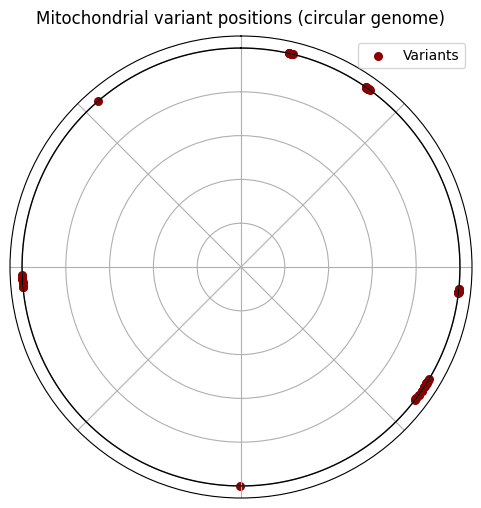

In [119]:
import matplotlib.pyplot as plt
import numpy as np


mt_genome_length = 16569
matching_variant_pos = [int(pos) for pos in matching_variant_pos]
# Convert positions to angles (radians)
angles = [2 * np.pi * (pos / mt_genome_length) for pos in matching_variant_pos]

# Create figure
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.set_theta_direction(-1)      # Clockwise
ax.set_theta_offset(np.pi / 2)  # Start from top

# Plot genome circle
ax.plot(np.linspace(0, 2*np.pi, 1000), [1]*1000, color='black', lw=1)

# Plot variant marks
ax.scatter(angles, [1]*len(angles), color='darkred', s=30, label='Variants')

# Clean up plot
ax.set_yticklabels([])  # Remove radial labels
ax.set_xticklabels([])  # Remove angular labels
ax.set_title("Mitochondrial variant positions (circular genome)", va='bottom')
ax.legend(loc='upper right')

plt.show()


In [121]:
## Trying to evaluate clonotyping 
import Py_mTCall_tools.clonotype_analysis
importlib.reload(Py_mTCall_tools.clonotype_analysis)

# Now import the confidence summary function directly
from Py_mTCall_tools.clonotype_analysis import get_variant_confidence_summary
from Py_mTCall_tools.clonotype_analysis import analyze_clonotypes_from_variants
from Py_mTCall_tools import (
    analyze_clonotypes_from_variants,
    plot_clonotype_vaf_heatmap,
    cluster_clonotypes,
    find_clonotypes
)

In [178]:
mgatk.obsm['variant_vaf_high_quality']
print(mgatk.obsm.keys())
print(list(mgatk.uns.keys()))

KeysView(AxisArrays with keys: X_umap, variant_vaf, variant_counts, variant_coverage, variant_confident, variant_vaf_high_quality, variant_vaf_high_quality_matrix)
['log1p', 'rank_genes_groups', 'celltype_colors', 'variant_summary', 'variant_names', 'clonotype_analysis', 'clonotype_stats', 'clonotype_leiden_colors', 'variant_vaf_high_quality_names']


In [168]:
##TESTING FUNCTION 
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
from scipy.spatial.distance import cosine, pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import warnings
def analyze_clonotypes_from_variants(adata, vaf_layer_name="vaf", min_cells=1, 
                                   min_vaf=0.1, min_coverage=20, min_strand_concordance=0.3,
                                   max_variance=1, resolution=1.0, k=10):
    """
    Perform clonotype analysis using only confidently detected variants.
    
    This function integrates with the process_and_integrate_variants output
    to perform clonotype analysis based on high-confidence variant allele frequencies.
    
    Args:
        adata (anndata.AnnData): AnnData object from process_and_integrate_variants
        vaf_layer_name (str): Name of the VAF layer (default: "vaf")
        min_cells (int): Minimum number of cells with confident variant detection
        min_vaf (float): Minimum VAF threshold for confident detection (default: 10%)
        min_coverage (float): Minimum mean coverage depth for a variant
        min_strand_concordance (float): Minimum strand concordance for confident detection
        max_variance (float): Maximum VAF variance across cells (filters noisy variants)
        resolution (float): Clustering resolution
        k (int): Number of neighbors for graph construction
    
    Returns:
        anndata.AnnData: Updated AnnData object with clonotype assignments
    """
    
    # Check if we have the VAF matrix from variant calling
    vaf_matrix_key = f'{vaf_layer_name}_matrix'
    if vaf_matrix_key not in adata.obsm:
        raise ValueError(f"VAF matrix '{vaf_matrix_key}' not found in adata.obsm. "
                        "Please run process_and_integrate_variants first.")
    
    # Get VAF matrix
    vaf_matrix = adata.obsm[vaf_matrix_key]
    
    # Filter variants based on confidence criteria
    if 'variant_summary' in adata.uns:
        variant_info = adata.uns['variant_summary']
        variant_names = adata.uns['variant_names']
        
        # Apply multiple confidence filters
        confidence_filters = {
            'sufficient_coverage': variant_info['mean_coverage'] >= min_coverage,
            'strand_concordance': (variant_info['strand_concordance'] >= min_strand_concordance) | 
                                 variant_info['strand_concordance'].isna(),  # Accept NaN (single-strand variants)
            'low_variance': variant_info['variance'] <= max_variance
        }
        
        # Combine all filters
        confident_variants = pd.Series(True, index=variant_info.index)
        for filter_name, filter_mask in confidence_filters.items():
            confident_variants = confident_variants & filter_mask
            print(f"After {filter_name}: {confident_variants.sum()} variants remaining")
        
        # Get selected variants
        selected_variant_indices = confident_variants[confident_variants].index
        # The indices are actually the variant names themselves, not positions
        selected_variants = list(selected_variant_indices)
        
        # Filter VAF matrix using boolean mask
        vaf_matrix_filtered = vaf_matrix[:, confident_variants]
        
        print(f"\nFinal selection: Using {len(selected_variants)} high-confidence variants for clonotype analysis")
        print(f"Filtering criteria applied:")
        print(f"  - Confidently detected in >= {min_cells} cells")
        print(f"  - VAF >= {min_vaf} in >= {min_cells} cells") 
        print(f"  - Mean coverage >= {min_coverage}x")
        print(f"  - Strand concordance >= {min_strand_concordance} (or single-strand)")
        print(f"  - VAF variance <= {max_variance}")
        
    else:
        # Use all variants if no filtering info available (fallback)
        vaf_matrix_filtered = vaf_matrix
        selected_variants = [f"variant_{i}" for i in range(vaf_matrix.shape[1])]
        
        print(f"Warning: No variant confidence info found. Using all {vaf_matrix.shape[1]} variants for clonotype analysis")
    
    # Create temporary AnnData object with VAF data
    adata_vaf = anndata.AnnData(X=vaf_matrix_filtered)
    adata_vaf.obs_names = adata.obs_names
    adata_vaf.var_names = selected_variants
    
    # Perform clonotype analysis
    adata_vaf = find_clonotypes(
        adata_vaf, 
        layer=None,  # Use X directly
        features=None,  # Use all selected variants
        resolution=resolution,
        k=k,
        algorithm='leiden'
    )
    
    # Transfer results back to original adata
    clonotype_col = 'clonotype_leiden'
    adata.obs[clonotype_col] = adata_vaf.obs[clonotype_col]
    
    # Transfer neighbor graph
    adata.obsp['clonotype_connectivities'] = adata_vaf.obsp['clonotype_connectivities']
    adata.obsp['clonotype_distances'] = adata_vaf.obsp['clonotype_distances']
    
    # Store clonotype-specific information
    adata.uns['clonotype_analysis'] = {
        'selected_variants': selected_variants,
        'n_variants_used': len(selected_variants),
        'min_cells_threshold': min_cells,
        'min_vaf_threshold': min_vaf,
        'hierarchy': adata_vaf.uns.get('clonotype_hierarchy', None)
    }
    
    # Calculate clonotype statistics
    clonotype_stats = []
    for clonotype in adata.obs[clonotype_col].cat.categories:
        clonotype_mask = adata.obs[clonotype_col] == clonotype
        n_cells = clonotype_mask.sum()
        
        # Get variants characteristic of this clonotype
        clonotype_vaf = vaf_matrix_filtered[clonotype_mask, :]
        mean_vaf = np.mean(clonotype_vaf, axis=0)
        
        # Find variants with high mean VAF in this clonotype
        high_vaf_variants = np.where(mean_vaf > min_vaf)[0]
        characteristic_variants = [selected_variants[i] for i in high_vaf_variants]
        
        clonotype_stats.append({
            'clonotype': clonotype,
            'n_cells': n_cells,
            'n_characteristic_variants': len(characteristic_variants),
            'characteristic_variants': characteristic_variants,
            'mean_vaf_all_variants': np.mean(mean_vaf)
        })
    
    adata.uns['clonotype_stats'] = pd.DataFrame(clonotype_stats)
    
    print(f"Identified {len(adata.obs[clonotype_col].cat.categories)} clonotypes")
    print(f"Clonotype sizes: {adata.obs[clonotype_col].value_counts().to_dict()}")
    
    return adata

In [182]:
##Filter the mgatk adata object for high quality variants prior to clonotyping
# Filter all the variant matrices
# Create a filtered copy of mgatk with only high-quality variants
mgatk_filtered = mgatk.copy()
mgatk_filtered.obsm['variant_vaf'] = mgatk.obsm['variant_vaf'][:, high_quality_mask]
mgatk_filtered.obsm['variant_vaf_high_quality'] = mgatk.obsm['variant_vaf_high_quality'][:, high_quality_mask]
mgatk_filtered.obsm['variant_coverage'] = mgatk.obsm['variant_coverage'][:, high_quality_mask]
mgatk_filtered.obsm['variant_confident'] = mgatk.obsm['variant_confident'][:, high_quality_mask]

# Filter the variant info
mgatk_filtered.uns['variant_names'] = list(high_quality_variant_names)
mgatk_filtered.uns['variant_summary'] = mgatk.uns['variant_summary'].iloc[high_quality_mask].reset_index(drop=True)

print(f"Filtered mgatk object now contains {len(mgatk_filtered.uns['variant_names'])} variants")

Filtered mgatk object now contains 2363 variants


In [184]:
# Use the high-quality filtered VAF matrix for clonotype analysis
mgatk_filtered.obsm['variant_vaf_high_quality_matrix'] = mgatk_filtered.obsm['variant_vaf_high_quality']
mgatk_with_clonotypes = analyze_clonotypes_from_variants(
    mgatk_filtered,
    vaf_layer_name="variant_vaf_high_quality",  # Use your high-quality filtered data              # High threshold since you WANT variance ≥0.01
    resolution=0.8,
    min_vaf=0.1,
    min_coverage=20,   
                              # Might need to adjust resolution
    k=10                           # Number of neighbors for graph construction
)


After sufficient_coverage: 2363 variants remaining
After strand_concordance: 2363 variants remaining
After low_variance: 2363 variants remaining

Final selection: Using 2363 high-confidence variants for clonotype analysis
Filtering criteria applied:
  - Confidently detected in >= 1 cells
  - VAF >= 0.1 in >= 1 cells
  - Mean coverage >= 20x
  - Strand concordance >= 0.3 (or single-strand)
  - VAF variance <= 1


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:844: UserWarning:


AnnData expects .var.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:844: UserWarning:


AnnData expects .var.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer




Identified 41 clonotypes
Clonotype sizes: {'clonotype_36': 3112, 'clonotype_40': 860, 'clonotype_25': 820, 'clonotype_8': 332, 'clonotype_22': 223, 'clonotype_37': 217, 'clonotype_34': 214, 'clonotype_35': 160, 'clonotype_30': 156, 'clonotype_29': 137, 'clonotype_24': 136, 'clonotype_27': 135, 'clonotype_32': 115, 'clonotype_28': 103, 'clonotype_14': 97, 'clonotype_31': 88, 'clonotype_33': 85, 'clonotype_26': 76, 'clonotype_9': 69, 'clonotype_17': 68, 'clonotype_1': 66, 'clonotype_4': 48, 'clonotype_5': 46, 'clonotype_2': 38, 'clonotype_19': 33, 'clonotype_3': 30, 'clonotype_23': 26, 'clonotype_16': 18, 'clonotype_21': 18, 'clonotype_10': 15, 'clonotype_39': 13, 'clonotype_0': 10, 'clonotype_38': 10, 'clonotype_7': 9, 'clonotype_18': 9, 'clonotype_11': 7, 'clonotype_15': 7, 'clonotype_20': 6, 'clonotype_12': 6, 'clonotype_6': 4, 'clonotype_13': 4}


Creating clonotype visualizations...


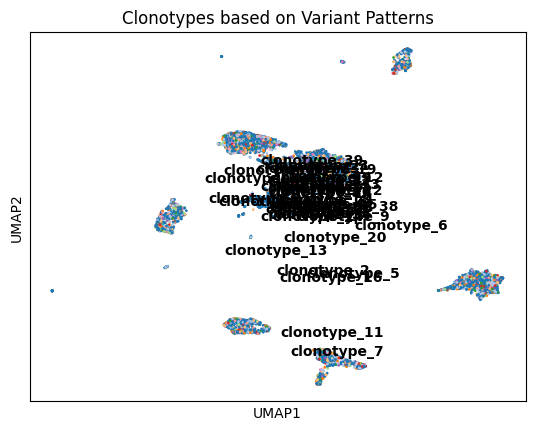

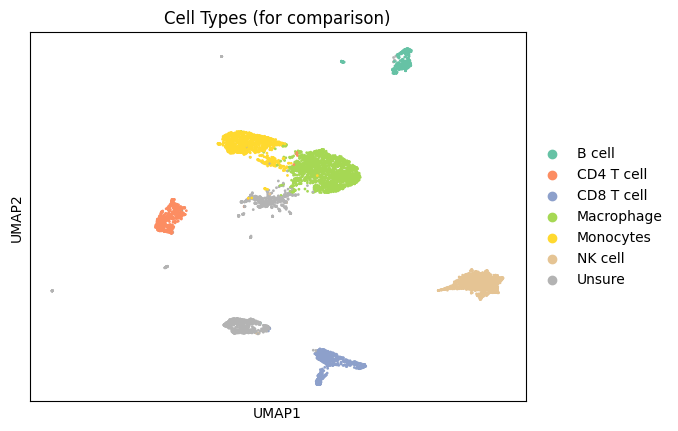

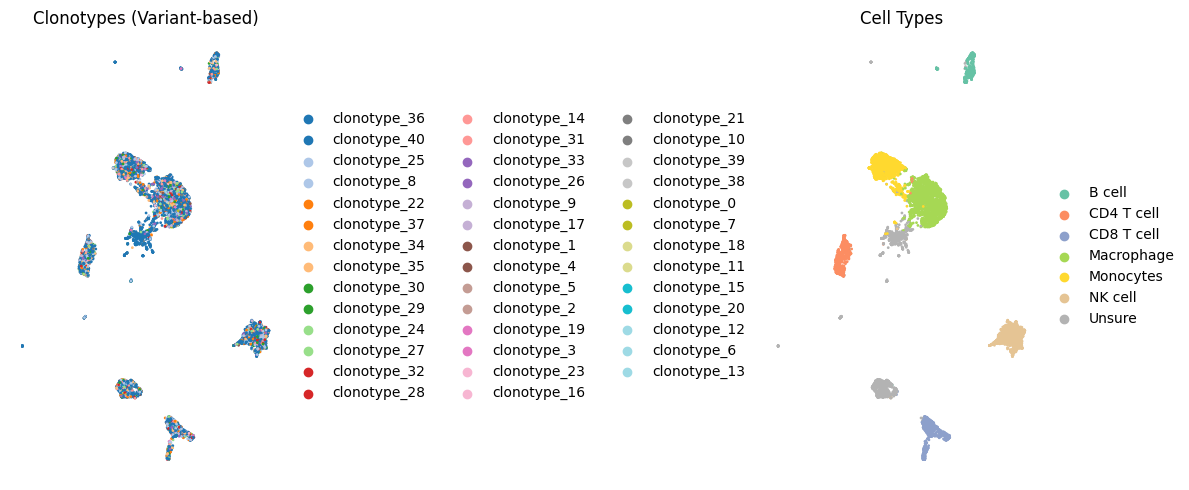

✓ UMAP visualizations created!


In [185]:
# Visualize clonotypes on UMAP
# Plot clonotype assignments overlaid on the UMAP embedding

print("Creating clonotype visualizations...")

# Plot clonotypes on UMAP
sc.pl.umap(
    mgatk_with_clonotypes, 
    color='clonotype_leiden', 
    legend_loc='on data',
    title='Clonotypes based on Variant Patterns',
    palette='tab20'
)

# Also show cell types for comparison
sc.pl.umap(
    mgatk_with_clonotypes, 
    color='celltype', 
    title='Cell Types (for comparison)',
    palette='Set2'
)

# Create a combined plot showing both
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Clonotypes
sc.pl.umap(
    mgatk_with_clonotypes, 
    color='clonotype_leiden', 
    ax=axes[0],
    show=False,
    frameon=False,
    title='Clonotypes (Variant-based)'
)

# Plot 2: Cell types
sc.pl.umap(
    mgatk_with_clonotypes, 
    color='celltype', 
    ax=axes[1], 
    show=False,
    frameon=False,
    title='Cell Types'
)

plt.tight_layout()
plt.show()

print("✓ UMAP visualizations created!")

Creating clonotype VAF heatmap...


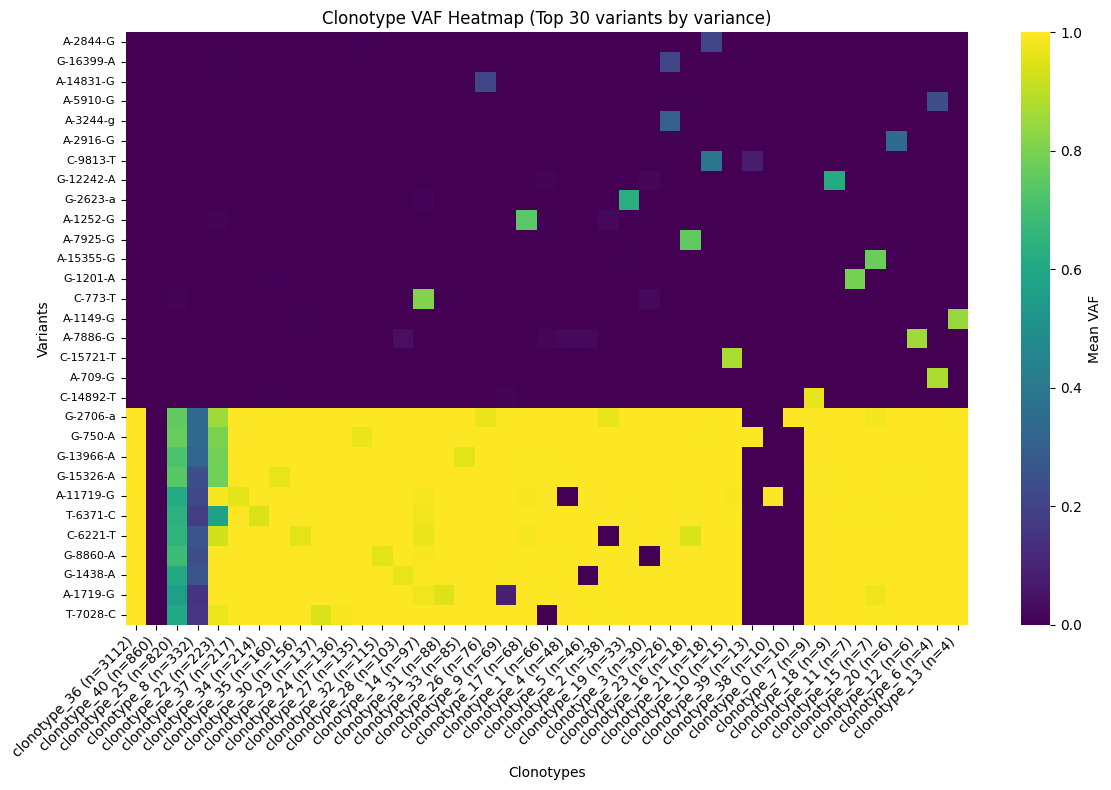

In [186]:
# Create clonotype VAF heatmap
# This shows which variants characterize each clonotype

print("Creating clonotype VAF heatmap...")

# Create heatmap showing VAF patterns across clonotypes
fig = plot_clonotype_vaf_heatmap(
    mgatk_with_clonotypes,
    vaf_layer_name="variant_vaf_high_quality",
    clonotype_col="clonotype_leiden",
    top_variants=30,  # Show top 30 most variable variants
    figsize=(12, 8)
)

# Get all axes in the figure
axes = fig.get_axes()

# Try different colormaps that work well for low values
colormaps_to_try = ['plasma', 'viridis', 'inferno', 'magma', 'RdYlBu_r', 'coolwarm']

# Get the heatmap image
for ax in fig.get_axes():
    images = ax.get_images()
    if images:
        # Change to a colormap with better low-value contrast
        images[0].set_cmap('plasma')  # This one is particularly good for low values
        
        # Optional: Use a custom normalization for better contrast
        from matplotlib.colors import PowerNorm
        images[0].set_norm(PowerNorm(gamma=0.5))  # gamma < 1 emphasizes low values
        
        break

plt.show()

Creating custom clonotype VAF heatmap with better color contrast...


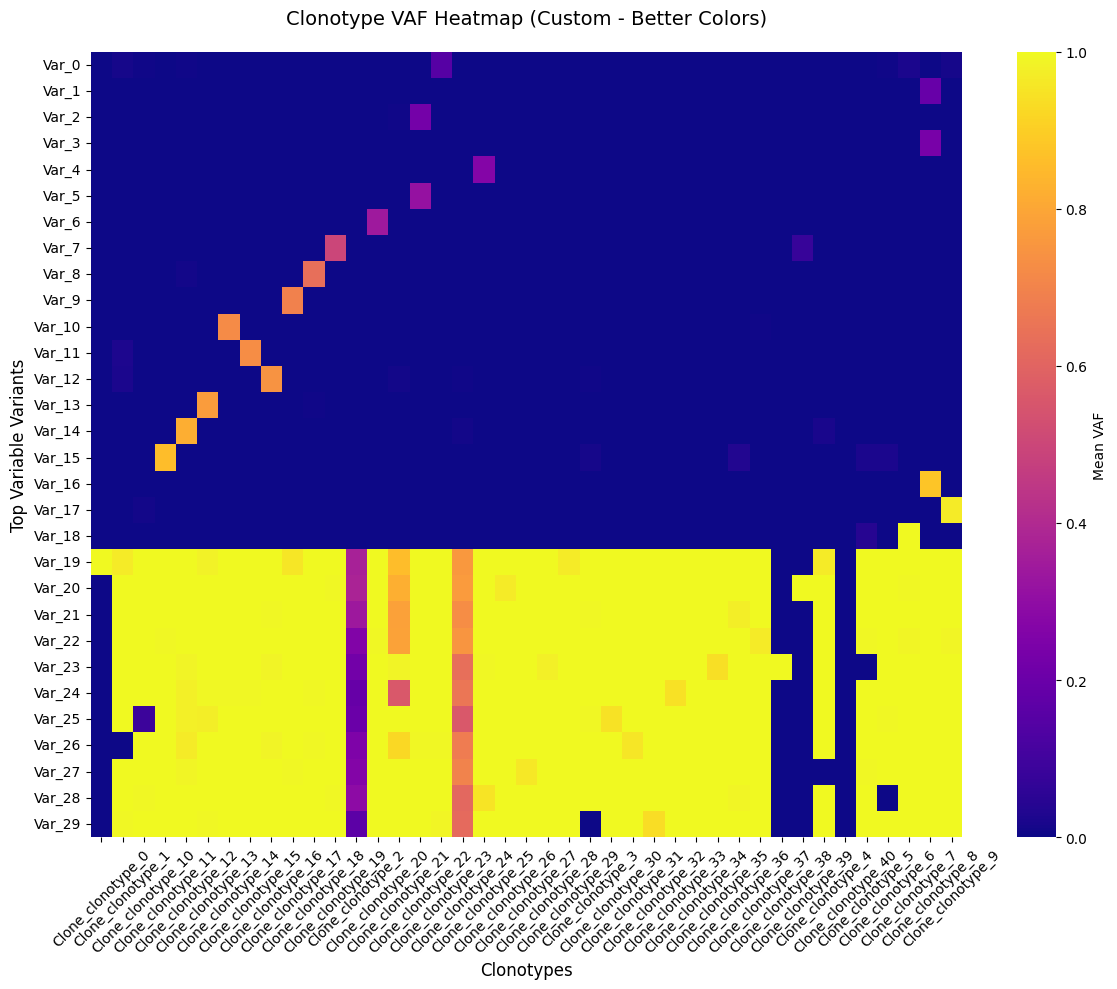

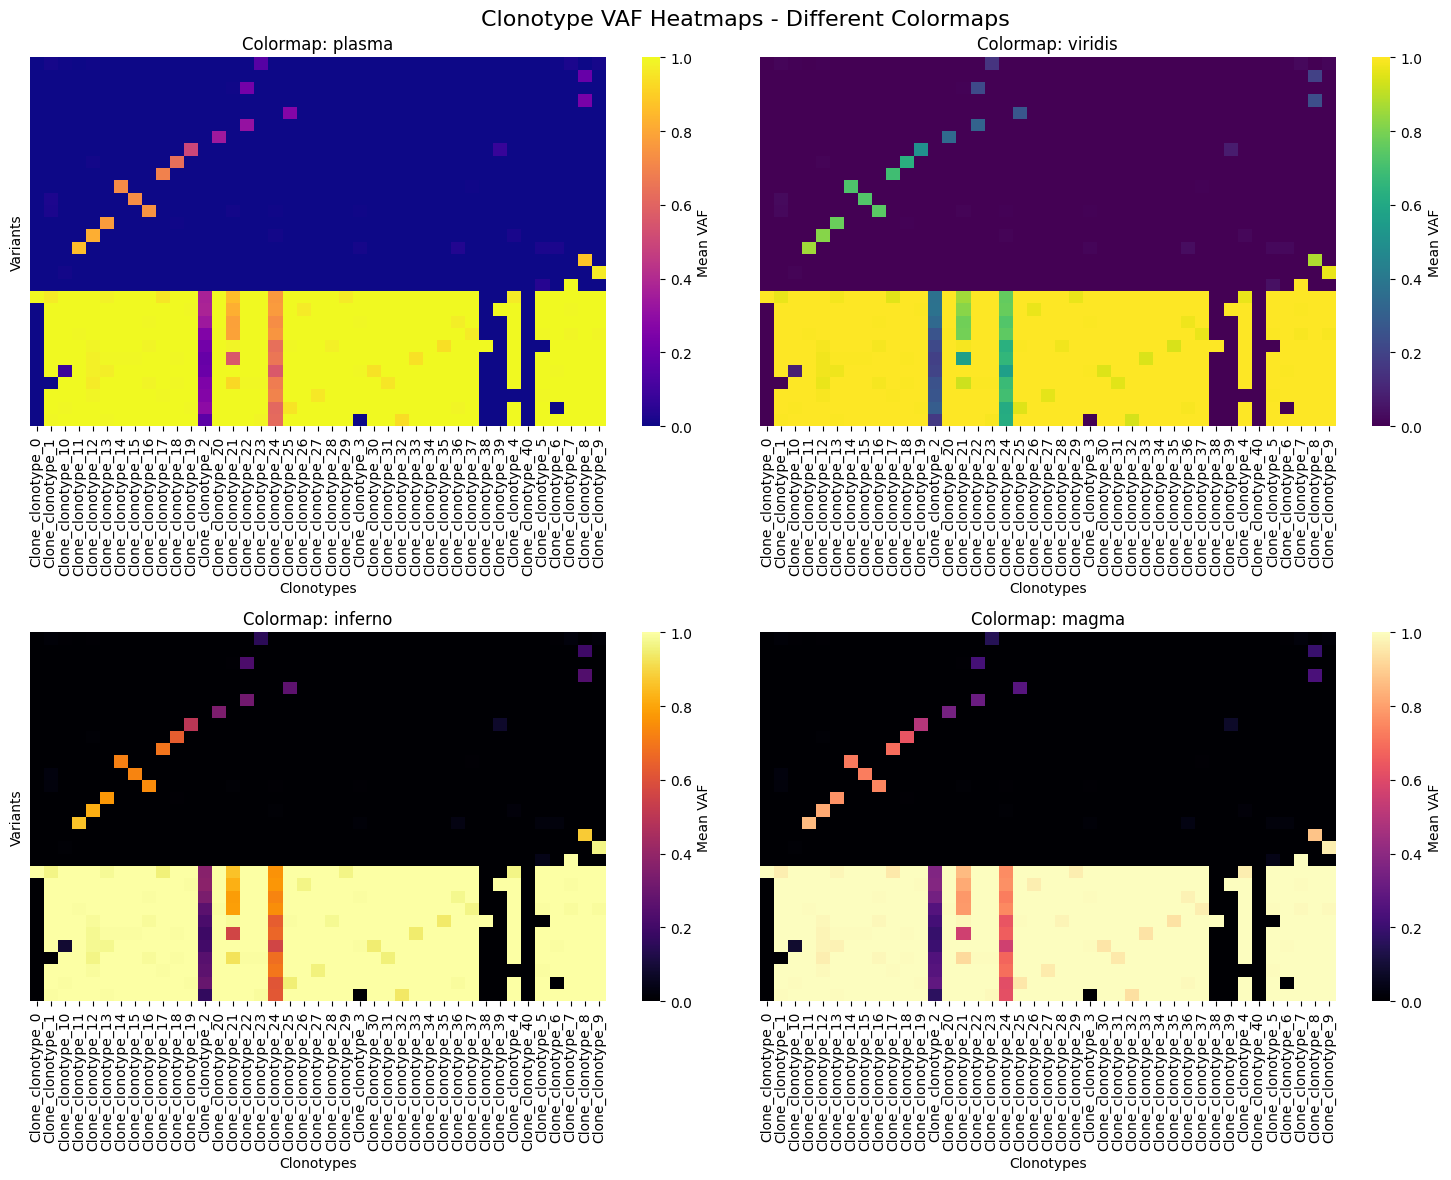

✓ Custom heatmaps created with better color contrast!


In [176]:
# Create your own custom clonotype VAF heatmap with better colors
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print("Creating custom clonotype VAF heatmap with better color contrast...")

# Get the data
vaf_matrix = mgatk_with_clonotypes.obsm['variant_vaf_high_quality']
clonotypes = mgatk_with_clonotypes.obs['clonotype_leiden']
variant_names = mgatk_with_clonotypes.uns['variant_names']

# Calculate mean VAF per clonotype
clonotype_means = []
clonotype_labels = []

for clono in sorted(clonotypes.cat.categories):
    mask = clonotypes == clono
    if mask.sum() > 0:
        mean_vaf = np.mean(vaf_matrix[mask, :], axis=0)
        clonotype_means.append(mean_vaf)
        clonotype_labels.append(f'Clone_{clono}')

clonotype_means = np.array(clonotype_means)

# Select top variable variants (same logic as the original function)
variant_variance = np.var(clonotype_means, axis=0)
top_variant_indices = np.argsort(variant_variance)[-30:]  # Top 30 most variable

# Get variant names for the selected variants
selected_variant_names = [variant_names[i] for i in top_variant_indices]

# Create the heatmap data
heatmap_data = clonotype_means[:, top_variant_indices].T  # Transpose: variants as rows, clonotypes as columns

# Create custom heatmap with better colormap
plt.figure(figsize=(12, 10))
sns.heatmap(
    heatmap_data,
    cmap='plasma',  # Much better for low values
    cbar=True,
    xticklabels=clonotype_labels,
    yticklabels=[f'Var_{i}' for i in range(len(selected_variant_names))],
    vmin=0,
    vmax=np.percentile(heatmap_data, 95),  # Use 95th percentile as max for better contrast
    cbar_kws={'label': 'Mean VAF'},
    annot=False,  # Set to True if you want values displayed
    fmt='.3f'
)

plt.title('Clonotype VAF Heatmap (Custom - Better Colors)', fontsize=14, pad=20)
plt.xlabel('Clonotypes', fontsize=12)
plt.ylabel('Top Variable Variants', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Also try with different colormaps
colormaps = ['plasma', 'viridis', 'inferno', 'magma']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, cmap in enumerate(colormaps):
    sns.heatmap(
        heatmap_data,
        cmap=cmap,
        ax=axes[i],
        cbar=True,
        xticklabels=clonotype_labels,
        yticklabels=False,  # Remove y-labels for cleaner look
        vmin=0,
        vmax=np.percentile(heatmap_data, 95),
        cbar_kws={'label': 'Mean VAF'}
    )
    axes[i].set_title(f'Colormap: {cmap}', fontsize=12)
    axes[i].set_xlabel('Clonotypes')
    if i == 0 or i == 2:  # Only show y-label on left plots
        axes[i].set_ylabel('Variants')

plt.suptitle('Clonotype VAF Heatmaps - Different Colormaps', fontsize=16)
plt.tight_layout()
plt.show()

print("✓ Custom heatmaps created with better color contrast!")

=== DEBUGGING CLONOTYPES ===
Clonotype categories: ['clonotype_0', 'clonotype_1', 'clonotype_10', 'clonotype_11', 'clonotype_12', 'clonotype_13', 'clonotype_14', 'clonotype_15', 'clonotype_16', 'clonotype_17', 'clonotype_18', 'clonotype_19', 'clonotype_2', 'clonotype_20', 'clonotype_21', 'clonotype_22', 'clonotype_23', 'clonotype_24', 'clonotype_25', 'clonotype_26', 'clonotype_27', 'clonotype_28', 'clonotype_29', 'clonotype_3', 'clonotype_30', 'clonotype_31', 'clonotype_32', 'clonotype_33', 'clonotype_34', 'clonotype_35', 'clonotype_36', 'clonotype_37', 'clonotype_38', 'clonotype_39', 'clonotype_4', 'clonotype_40', 'clonotype_5', 'clonotype_6', 'clonotype_7', 'clonotype_8', 'clonotype_9']
Clonotype value counts:
clonotype_leiden
clonotype_36    3112
clonotype_40     860
clonotype_25     820
clonotype_8      332
clonotype_22     223
clonotype_37     217
clonotype_34     214
clonotype_35     160
clonotype_30     156
clonotype_29     137
clonotype_24     136
clonotype_27     135
clonotype

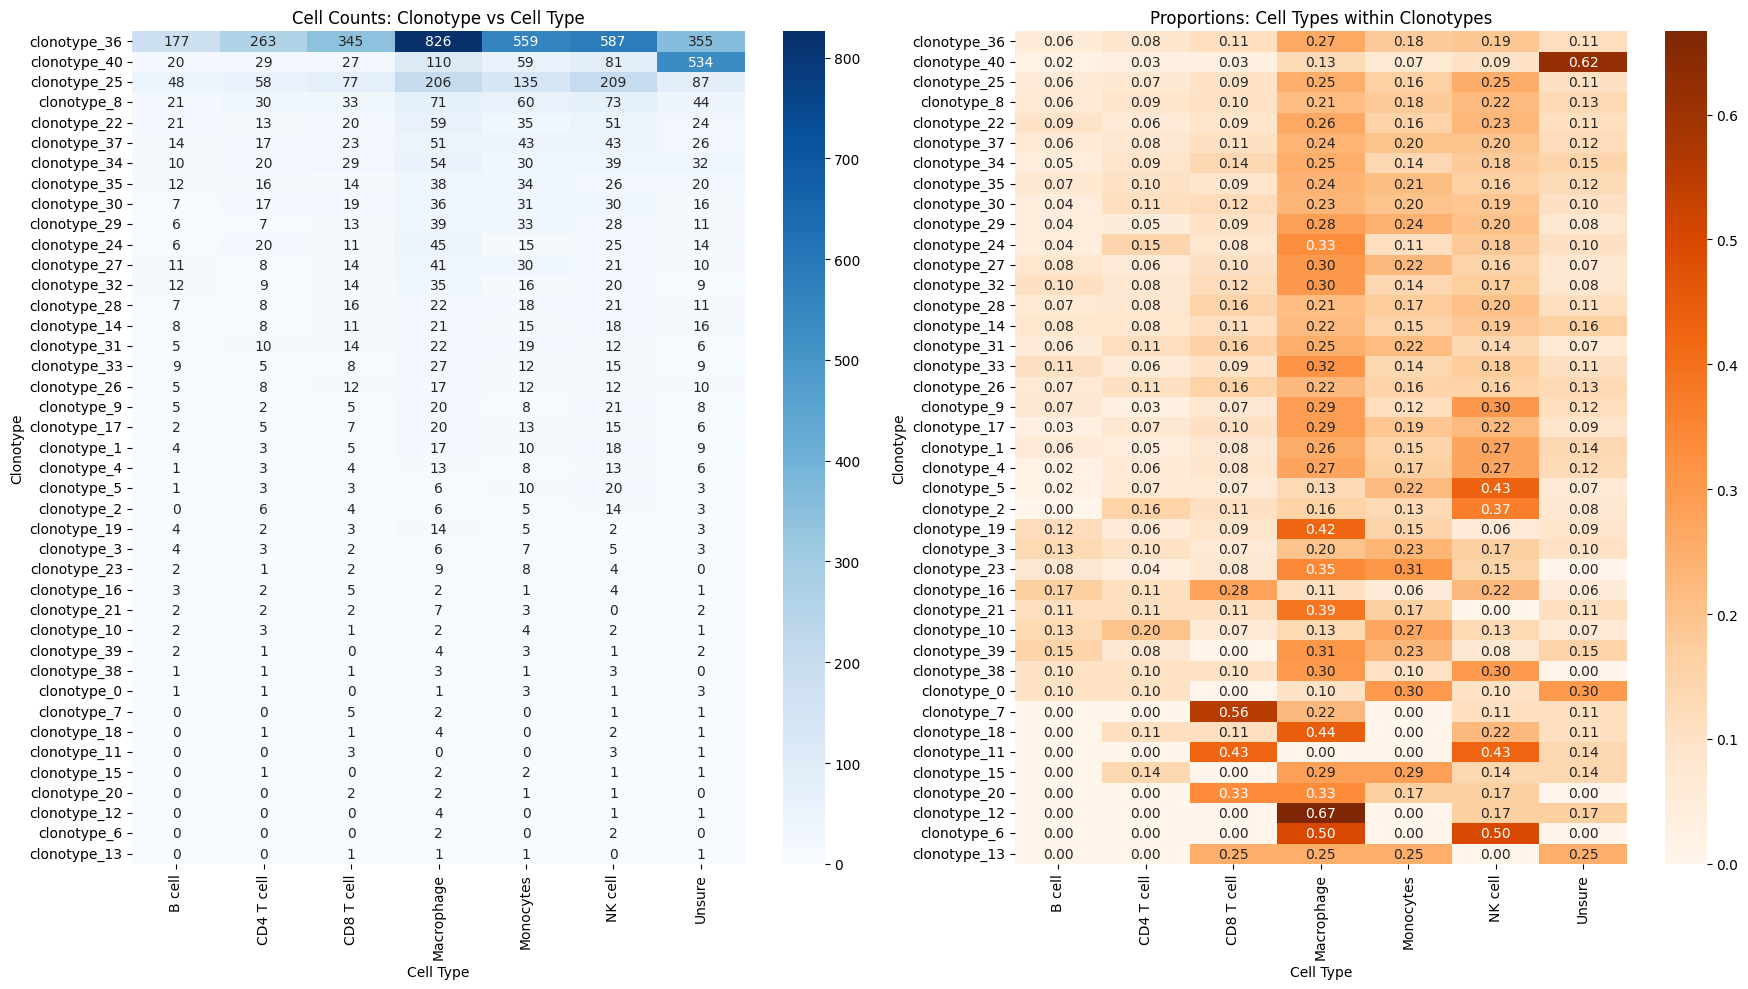

✓ Clonotype-cell type analysis completed!


In [193]:
# First, let's debug what clonotypes we actually have
print("=== DEBUGGING CLONOTYPES ===")
print("Clonotype categories:", sorted(mgatk_with_clonotypes.obs['clonotype_leiden'].cat.categories))
print("Clonotype value counts:")
print(mgatk_with_clonotypes.obs['clonotype_leiden'].value_counts().sort_index())

# Create both crosstabs with all clonotypes
clonotype_celltype_crosstab_no_margins = pd.crosstab(
    mgatk_with_clonotypes.obs['clonotype_leiden'], 
    mgatk_with_clonotypes.obs['celltype']
)

clonotype_celltype_props = pd.crosstab(
    mgatk_with_clonotypes.obs['clonotype_leiden'], 
    mgatk_with_clonotypes.obs['celltype'],
    normalize='index'  # Normalize by rows (clonotypes)
)

print("Crosstab shape:", clonotype_celltype_crosstab_no_margins.shape)
print("Crosstab index:", sorted(clonotype_celltype_crosstab_no_margins.index))

# Now create the plots
fig, axes = plt.subplots(1, 2, figsize=(18, 10))  # Make it bigger to fit all clonotypes

# Plot 1: Absolute counts
sns.heatmap(clonotype_celltype_crosstab_no_margins, 
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Cell Counts: Clonotype vs Cell Type')
axes[0].set_xlabel('Cell Type')
axes[0].set_ylabel('Clonotype')

# Plot 2: Proportions  
sns.heatmap(clonotype_celltype_props, 
            annot=True, fmt='.2f', cmap='Oranges', ax=axes[1])
axes[1].set_title('Proportions: Cell Types within Clonotypes')
axes[1].set_xlabel('Cell Type')
axes[1].set_ylabel('Clonotype')

plt.tight_layout()
plt.show()

print("✓ Clonotype-cell type analysis completed!")